# Get profile of relevant genes



In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ploting_profiles import *

In [62]:
experiment_palette= {'GSE164471':'gold',
'GSE152558':'darkgreen',
'GSE157585':'aquamarine',
'GSE167186':'darkblue',
'GSE60590':'chocolate',
'GSE129643':'tomato'}

In [2]:
gene_sets = load_gene_data_with_metadata('data/selected_genes_all_symbol.csv')

In [3]:
gene_set_last = len(gene_sets)-1
genes=gene_sets[gene_set_last]['genes']

In [4]:
genes

['GABRP',
 'HCFC1R1',
 'MICU1',
 'PARK7',
 'SBDS',
 'MEIS2',
 'ALDOA',
 'FAM177A1',
 'TSPAN7',
 'SCGB3A2',
 'CA3',
 'B2M',
 'PKIA',
 'FEZ2',
 'SMIM37',
 'R3HDM2',
 'EIF3C',
 'UBE2H',
 'CALM1',
 'RNA5SP68',
 'RNA5SP237',
 'AC105272.1',
 'MTCO1P12',
 'RNA5SP148']

In [4]:
expression_data = pd.read_csv('data/RNAseq_z_score_adjustedCombat_symbols.csv')
male_expression = pd.read_csv('data/RNAseq_z_score_adjustedCombat_symbols_male.csv', index_col=0)
female_expression = pd.read_csv('data/RNAseq_z_score_adjustedCombat_symbols_female.csv', index_col=0)


In [6]:
male_expression.head()

,Sample,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC134980.5,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1,Age,Experiment,Sex
0,SRR13388732,-0.024640,-0.027469,-0.007903,-0.026124,-0.026015,-0.026864,-0.021406,-0.022678,-0.022670,...,-0.027306,-0.027267,-0.026753,-0.027502,-0.027457,-0.024058,-0.027476,23.0,GSE164471,Male
1,SRR13388733,-0.025765,-0.032593,-0.006575,-0.027678,-0.031369,-0.031862,-0.016857,-0.026578,-0.023808,...,-0.032575,-0.032619,-0.031722,-0.032605,-0.032541,-0.020310,-0.031807,28.0,GSE164471,Male
2,SRR13388734,-0.030008,-0.036930,-0.005061,-0.034131,-0.029369,-0.037718,-0.015247,-0.030479,-0.027006,...,-0.038608,-0.038491,-0.037602,-0.038201,-0.038558,-0.036063,-0.037850,31.0,GSE164471,Male
3,SRR13388735,-0.021340,-0.023615,-0.006280,-0.022375,-0.023463,-0.023325,-0.020330,-0.021371,-0.022376,...,-0.023718,-0.023678,-0.023091,-0.023741,-0.023709,-0.020413,-0.023409,31.0,GSE164471,Male
6,SRR13388738,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,...,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0,GSE164471,Male


In [5]:
expression_data_mf= pd.concat([male_expression, female_expression], axis=0)

In [17]:
expression_data_mf.head()

,Sample,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1,Age,Experiment,Sex,Age Group
0,SRR13388732,-0.024640,-0.027469,-0.007903,-0.026124,-0.026015,-0.026864,-0.021406,-0.022678,-0.022670,...,-0.027267,-0.026753,-0.027502,-0.027457,-0.024058,-0.027476,23.0,GSE164471,Male,Young
1,SRR13388733,-0.025765,-0.032593,-0.006575,-0.027678,-0.031369,-0.031862,-0.016857,-0.026578,-0.023808,...,-0.032619,-0.031722,-0.032605,-0.032541,-0.020310,-0.031807,28.0,GSE164471,Male,Young
2,SRR13388734,-0.030008,-0.036930,-0.005061,-0.034131,-0.029369,-0.037718,-0.015247,-0.030479,-0.027006,...,-0.038491,-0.037602,-0.038201,-0.038558,-0.036063,-0.037850,31.0,GSE164471,Male,Young
3,SRR13388735,-0.021340,-0.023615,-0.006280,-0.022375,-0.023463,-0.023325,-0.020330,-0.021371,-0.022376,...,-0.023678,-0.023091,-0.023741,-0.023709,-0.020413,-0.023409,31.0,GSE164471,Male,Young
6,SRR13388738,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,...,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0,GSE164471,Male,Middle Age


In [ ]:
create_violin_pdf(gene_data = expression_data, genes=genes, output_file="data/intersection_all_violin_plots_age.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_age)


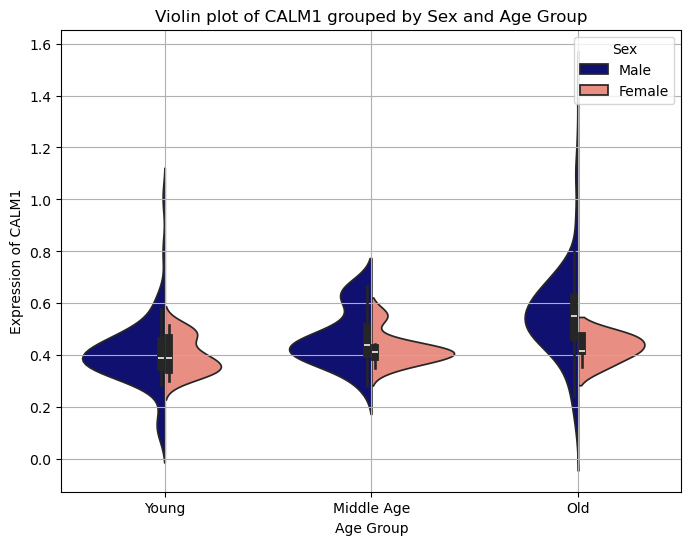

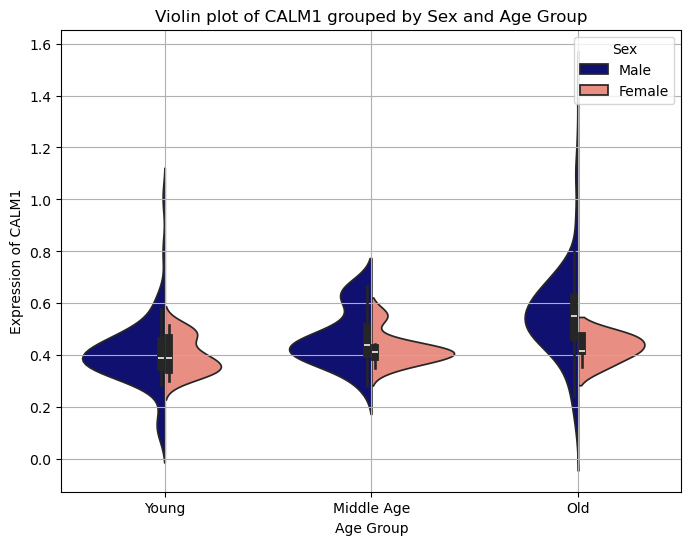

In [16]:
gene = 'CALM1'
save_name = f'plots/maleFemale_{gene}_vp.jpg'
palette = {'Male': 'navy', 'Female': 'salmon'}
violin_plot_grouped_by_sex_and_age_group(gene_data=expression_data_mf, gene=gene, palete=palette, save=save_name)


In [25]:
def scatter_plot_expression_over_age_and_sex(gene_data, gene, save=None, plot=True, palette={'Male': 'blue', 'Female': 'pink'}):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=gene_data['Age'], y=gene_data[gene], hue=gene_data['Sex'], palette=palette, legend='full')
    plt.title(f"Expression of {gene} across Age")
    plt.xlabel("Age")
    plt.ylabel(f"Expression of {gene}")
    plt.grid(True)
    if save:
        plt.savefig(save)
    plt.show()
def scatter_plot_expression_over_age_and_experiment(gene_data, gene, save=None, plot=True, palette=None):
    if palette is None:
        palette = experiment_palette
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=gene_data['Age'], y=gene_data[gene], hue=gene_data['Experiment'], palette=palette, legend='full')
    plt.title(f"Expression of {gene} across Age")
    plt.xlabel("Age")
    plt.ylabel(f"Expression of {gene}")
    plt.grid(True)
    if save:
        plt.savefig(save)
    plt.show()

In [91]:
from matplotlib.colors import to_rgba

def scatter_plot_expression_over_age_and_sex_experiment(gene_data, gene, save=None, plot=True, sex_palette=None, experiment_palette=None):
    # Default palettes
    if sex_palette is None:
        sex_palette = {'Male': 'navy', 'Female': 'salmon'}
    if experiment_palette is None:
        experiment_palette = {
            'GSE164471 Male': 'yellowgreen',
            'GSE152558 Male': 'darkgreen',
            'GSE157585 Male': 'teal',
            'GSE167186 Male': 'xkcd:azure',
            'GSE60590 Male': 'grey',
            'GSE129643 Male': 'purple',
            'GSE164471 Female': 'gold',
            'GSE152558 Female': 'orange',
            'GSE157585 Female': 'xkcd:orange',
            'GSE167186 Female': 'siena',
            'GSE60590 Female': 'red',
            'GSE129643 Female': 'maroon'
        }

    gene_data['Color'] = gene_data['Experiment']+' '+gene_data['Sex']

    # Map Sex to markers
    marker_palette = {'Male': 'o', 'Female': 's'}  # Squares for males, circles for females

    # Create the plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=gene_data['Age'],
        y=gene_data[gene],
        hue=gene_data['Color'],  # Experiment for colors
        style=gene_data['Sex'],  # Sex for marker shapes
        palette=experiment_palette,  # Color palette for experiments
        markers=marker_palette,  # Marker shapes for sex
        s=100,  # Marker size
        legend='full'  # Full legend
    )
    
    # Title and labels
    plt.title(f"Expression of {gene} across Age, Sex, and Experiment")
    plt.xlabel("Age")
    plt.ylabel(f"Expression of {gene}")
    plt.grid(True)

    # Adjust the legend
    plt.legend(
        title="Legend",
        bbox_to_anchor=(1.05, 1),  # Move the legend to the right
        loc='upper left',  # Position at the top left of the anchor box
        borderaxespad=0  # Reduce padding
    )

    # Save the plot if a file path is provided
    if save:
        plt.savefig(save, bbox_inches='tight')  # Use bbox_inches to ensure full legend is saved
    
    # Show the plot
    if plot:
        plt.show()

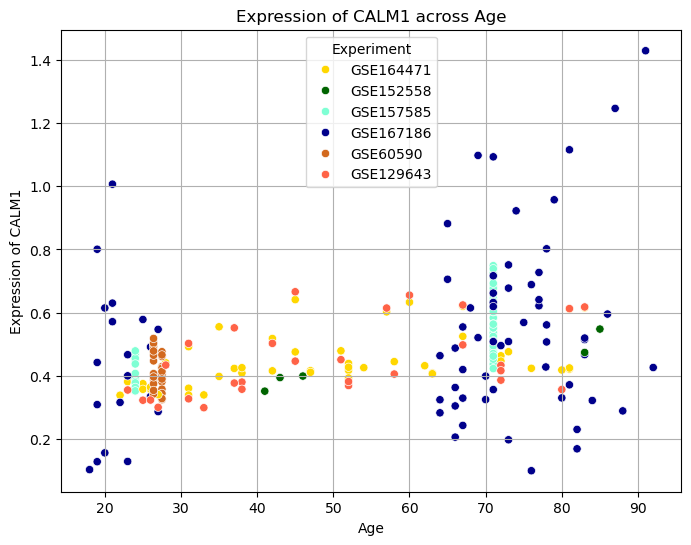

In [63]:
save_name = f'plots/experiment_color_{gene}_sp.jpg'
scatter_plot_expression_over_age_and_experiment(gene_data=expression_data_mf, gene=gene, save=save_name, plot=True, palette=experiment_palette)

In [69]:
expression_data_mf.columns

Index(['Sample', 'TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH',
       'FUCA2', 'GCLC',
       ...
       'AC021097.2', 'AC135068.11', 'AC010616.2', 'AL034430.1', 'AP000646.1',
       'Age', 'Experiment', 'Sex', 'Age Group', 'Color'],
      dtype='object', length=34511)

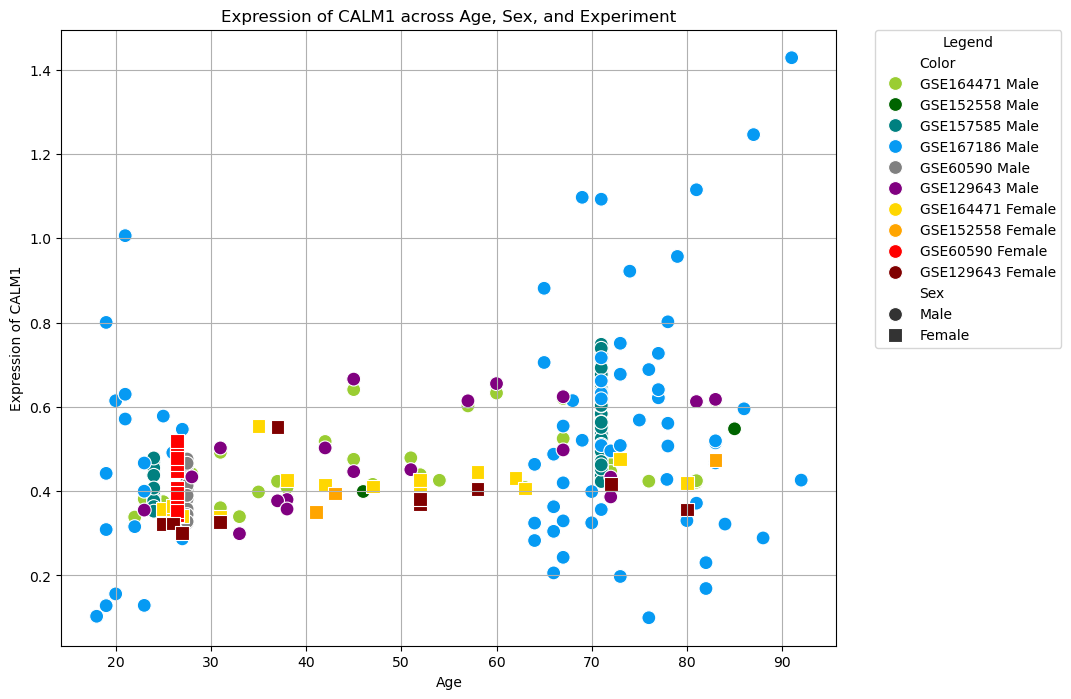

In [92]:
scatter_plot_expression_over_age_and_sex_experiment(gene_data=expression_data_mf, gene=gene, save=False, plot=True)

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def box_plot_expression_by_age_and_sex(
    gene_data, gene, save=None, plot=True, sex_palette=None
):
    # Default palette
    if sex_palette is None:
        sex_palette = {'Male': 'navy', 'Female': 'salmon'}
    
    # Create age groups in 10-year intervals
    gene_data['Age Group'] = pd.cut(
        gene_data['Age'], 
        bins=np.arange(0, gene_data['Age'].max() + 10, 10), 
        right=False
        
    )

    # Initialize the figure
    plt.figure(figsize=(12, 8))
    
    # Create the box plots
    sns.boxplot(
        x='Age Group',
        y=gene,
        hue='Sex',
        data=gene_data,
        palette=sex_palette
    )
    
    # Customize the plot
    plt.title(f"Expression of {gene} Across Age Groups by Sex", fontsize=16)
    plt.xlabel("Age Group", fontsize=14)
    plt.ylabel(f"Expression of {gene}", fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Sex", fontsize=12, title_fontsize=14)
    
    # Save the plot if a file path is provided
    if save:
        plt.savefig(save, bbox_inches='tight')
    
    # Show the plot
    if plot:
        plt.show()
    return fig

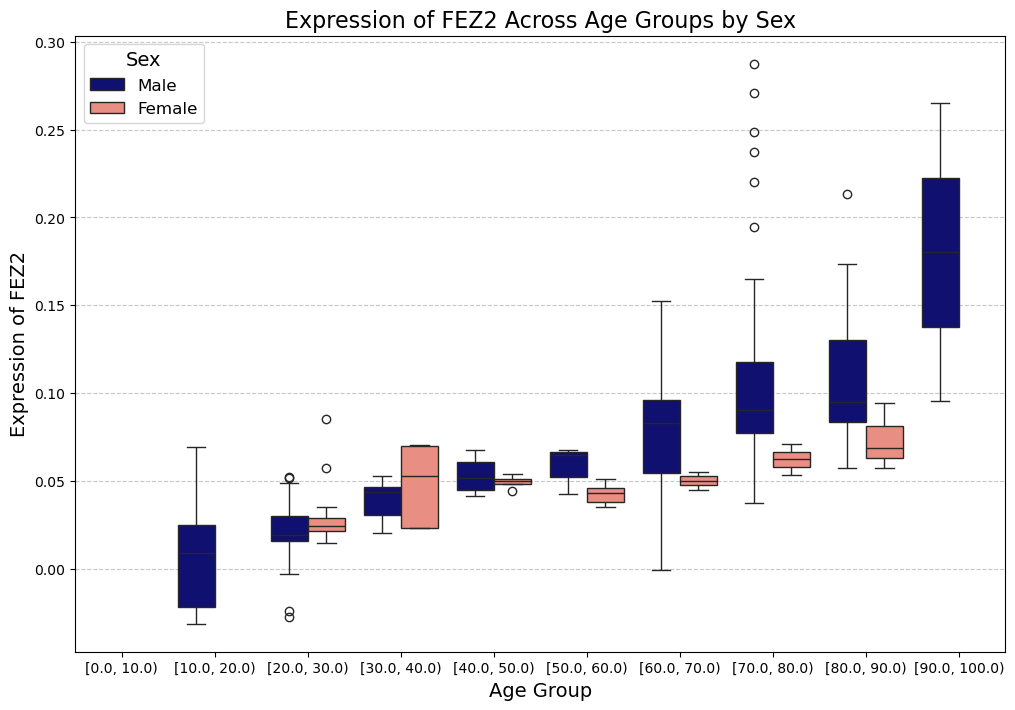

In [103]:
gene = 'FEZ2'
box_plot_expression_by_age_and_sex(expression_data_mf, gene)


In [29]:
experiment_palette

{'GSE164471': 'gold',
 'GSE152558': 'darkgreen',
 'GSE157585': 'cyan',
 'GSE167186': 'darkblue',
 'GSE60590': 'teal',
 'GSE129643': 'tomato'}

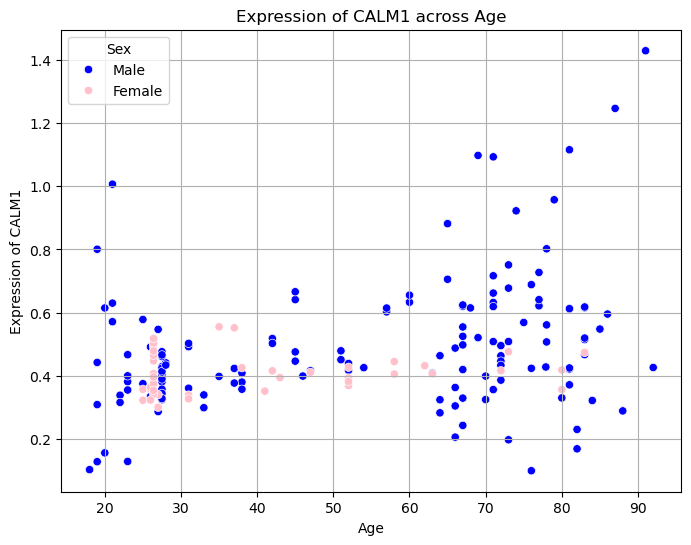

In [28]:
save_name = f'plots/maleFemale_{gene}_sp.jpg'

scatter_plot_expression_over_age_and_sex(gene_data=expression_data_mf[expression_data_mf['Experiment']!='GSE157585'], gene=gene, save=save_name, plot=True, palette={'Male': 'blue', 'Female': 'pink'})

In [20]:
expression_data_mf['Experiment'].unique()

array(['GSE164471', 'GSE152558', 'GSE157585', 'GSE167186', 'GSE60590',
       'GSE129643'], dtype=object)

In [ ]:

create_violin_pdf(gene_data = expression_data_mf, genes=genes, output_file="data/intersection_all_violin_plots_age_sex.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_sex_and_age_group)


In [ ]:
create_violin_pdf(gene_data = female_expression, genes=genes, output_file="data/intersection_all_violin_plots_female.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_age, color='pink')
create_violin_pdf(gene_data = male_expression, genes=genes, output_file="data/intersection_all_violin_plots_male.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_age,  color='blue')

In [18]:
get_change_curve(female_expression, 'R3HDM2')

'CAA'

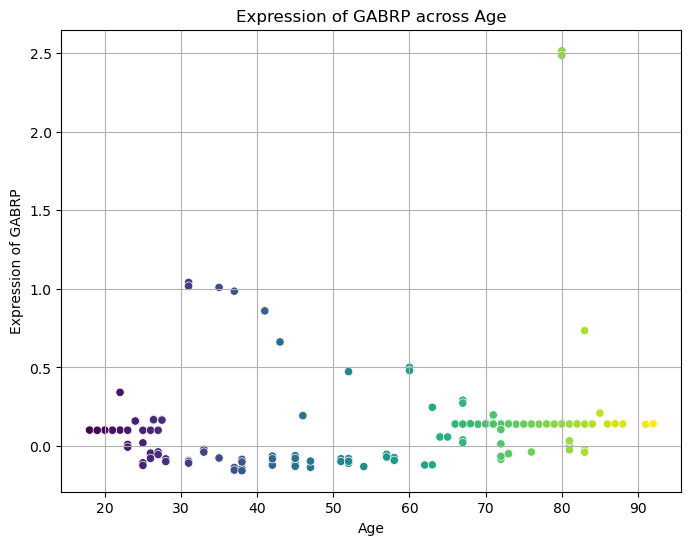

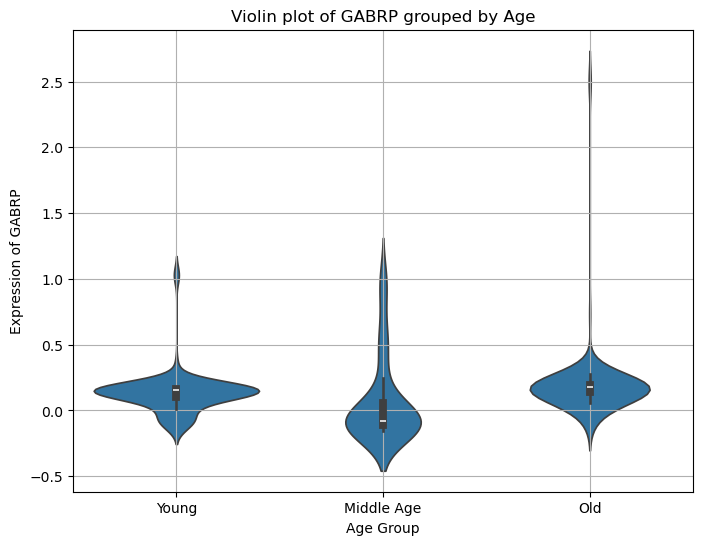

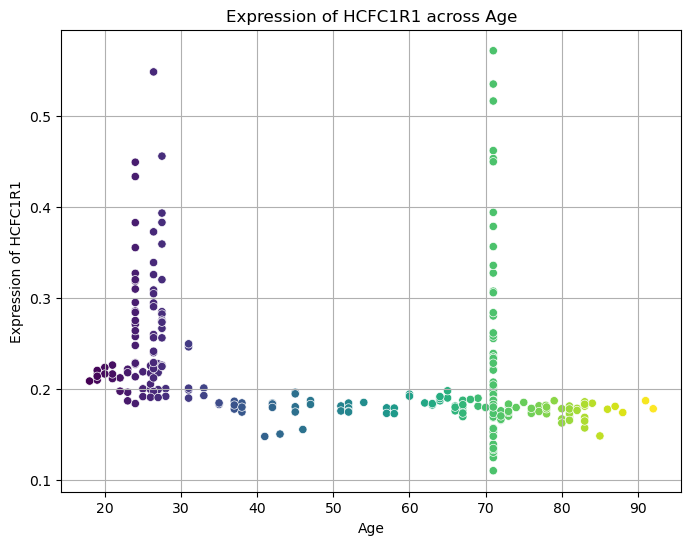

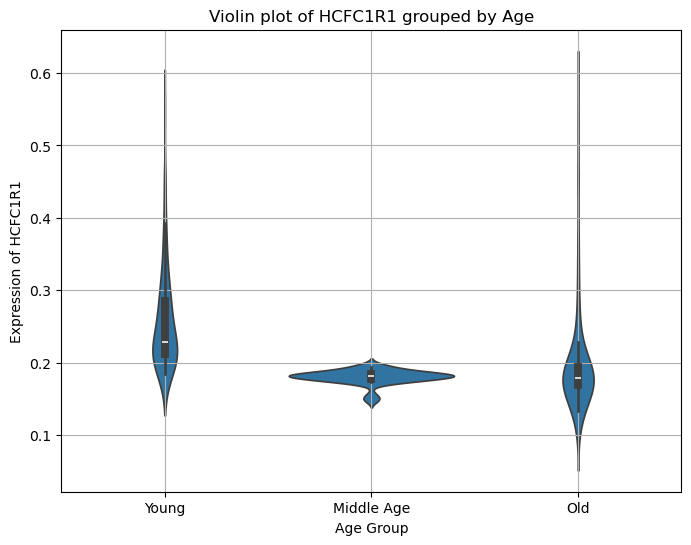

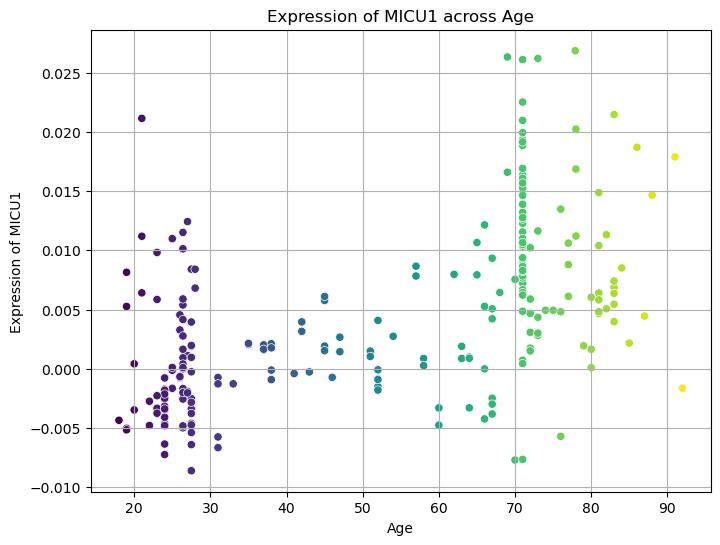

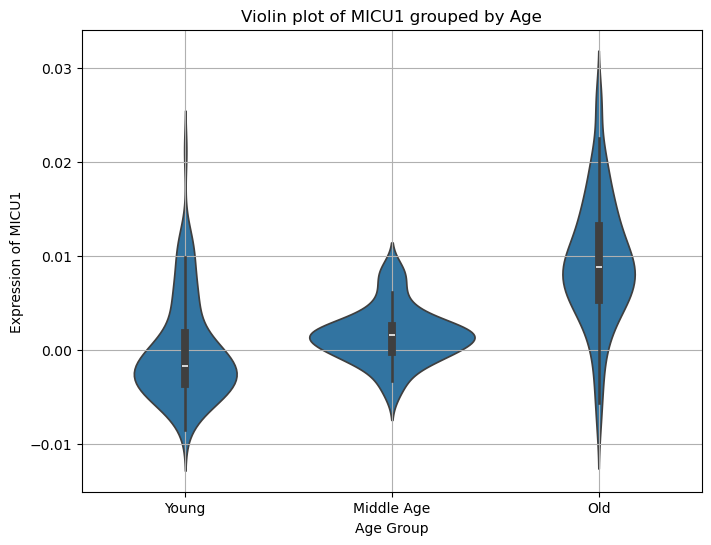

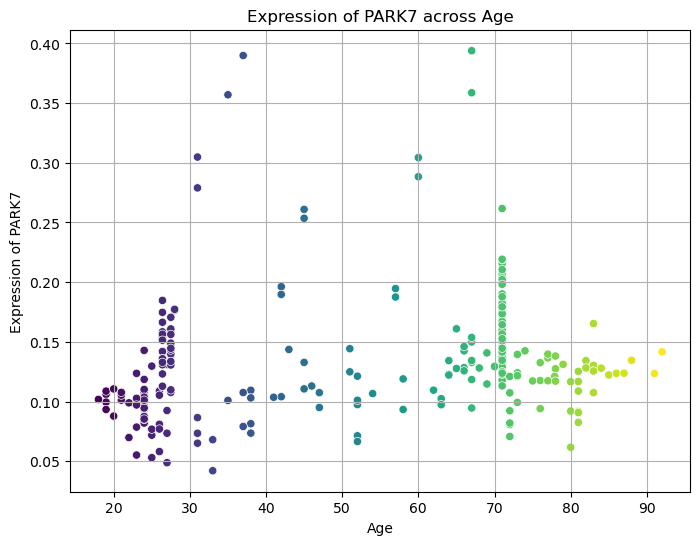

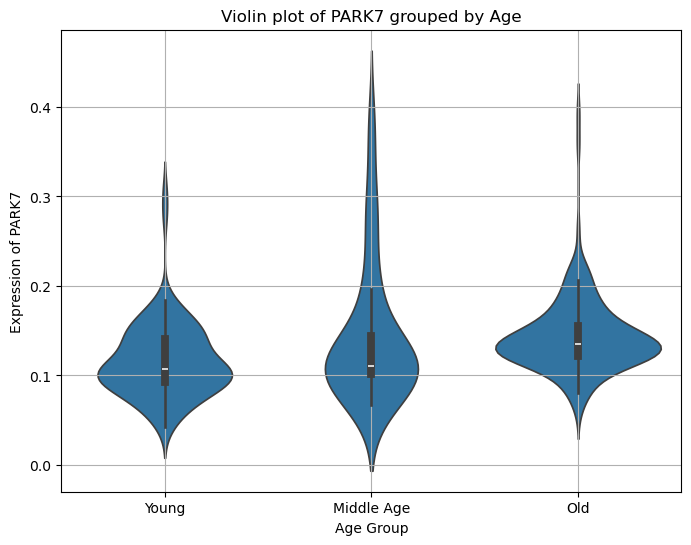

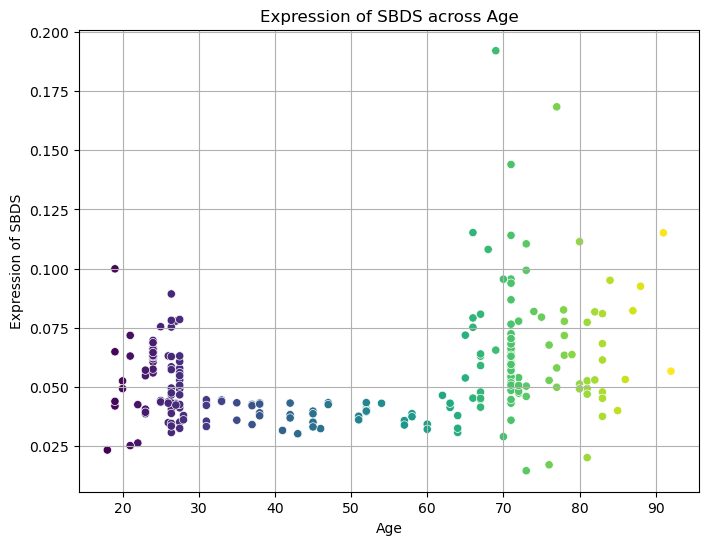

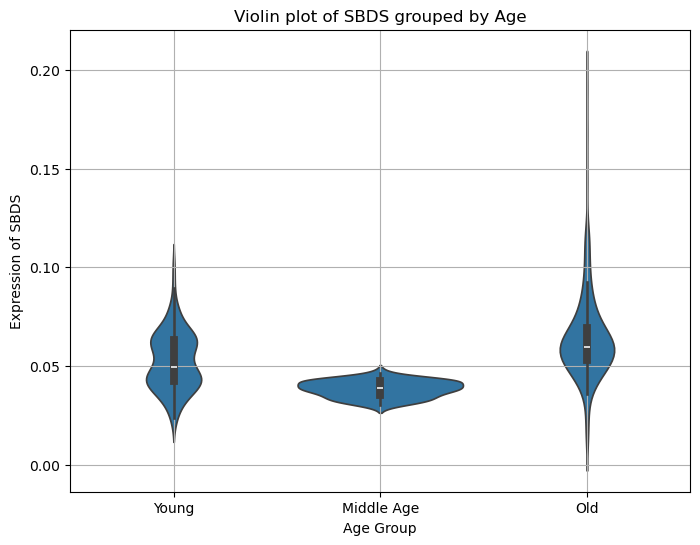

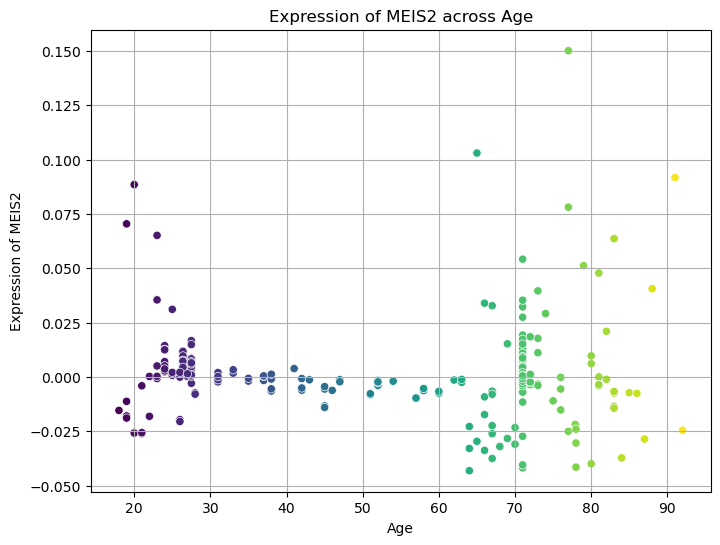

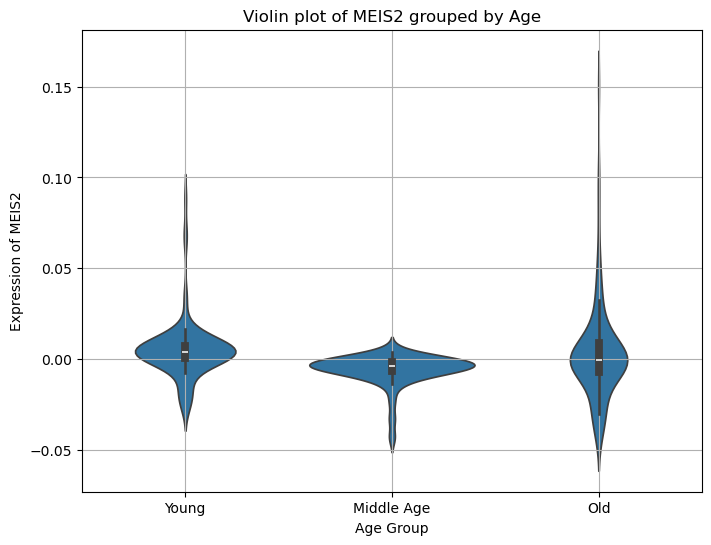

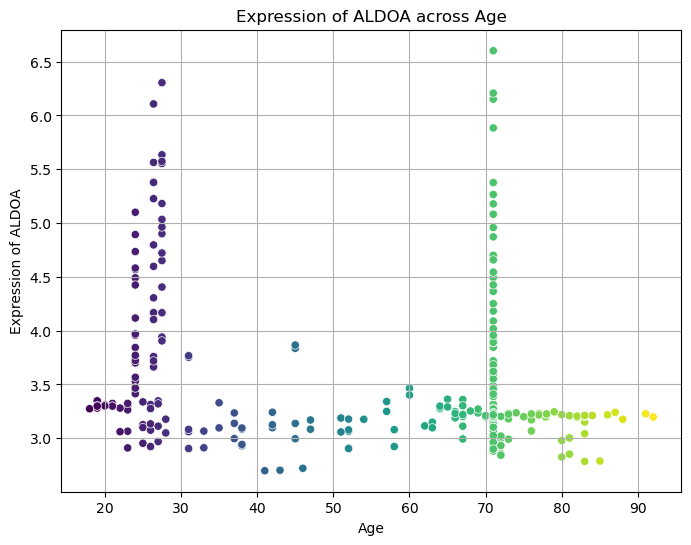

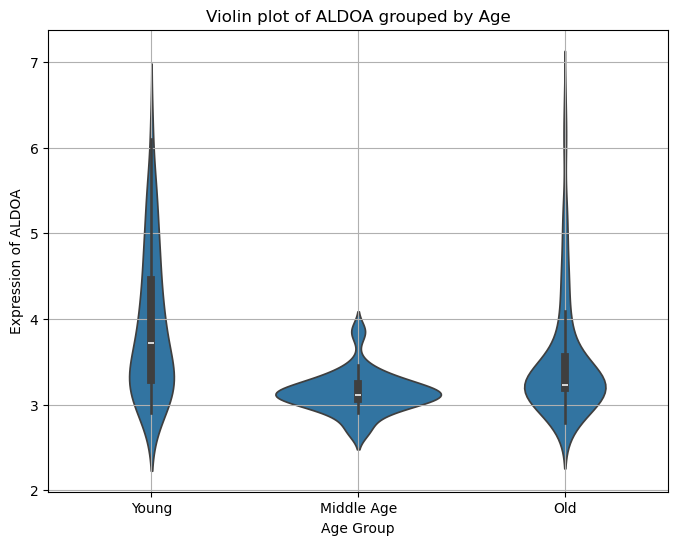

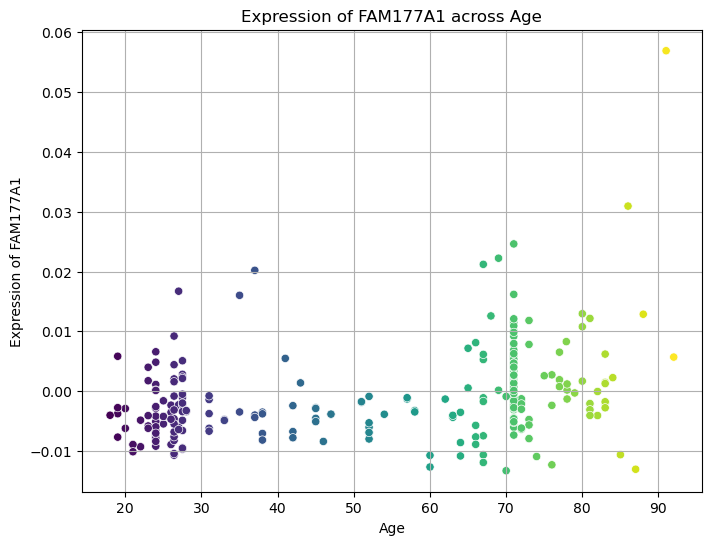

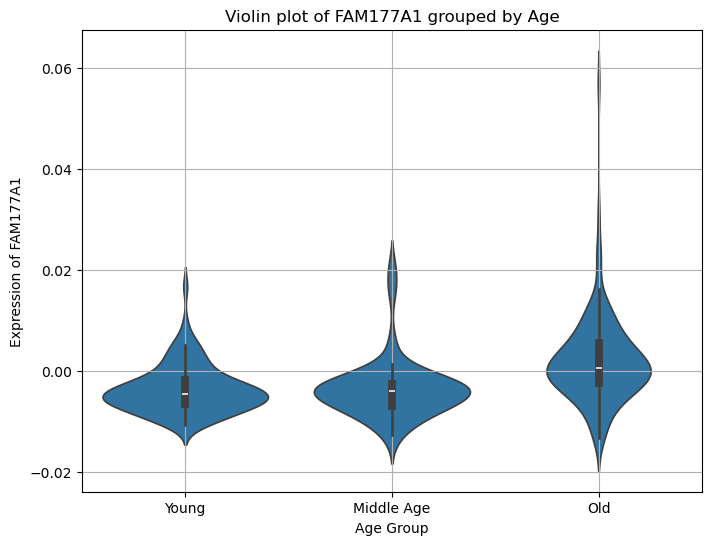

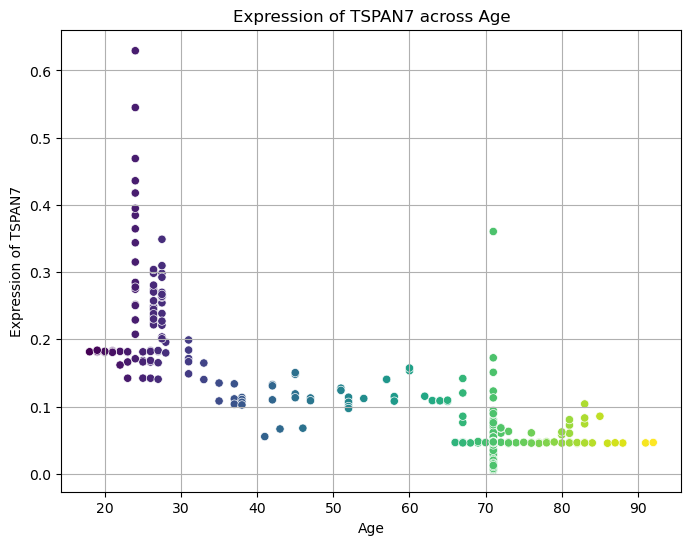

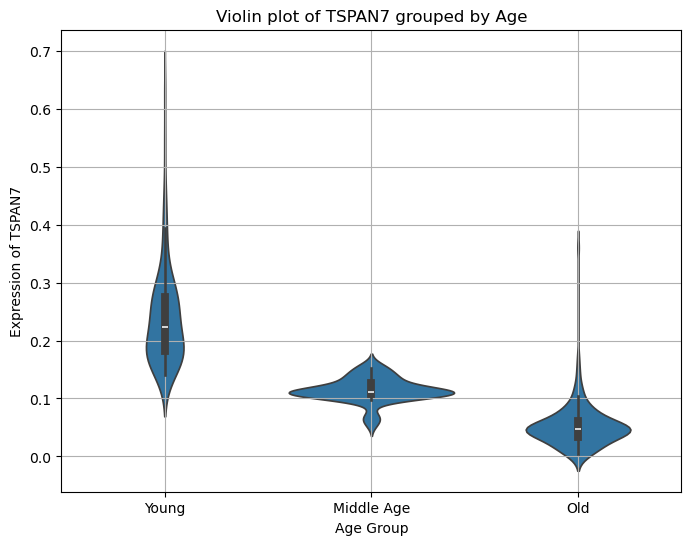

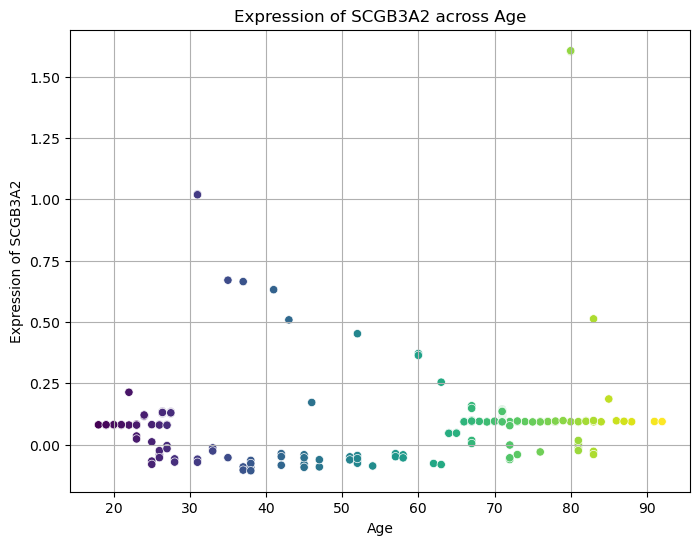

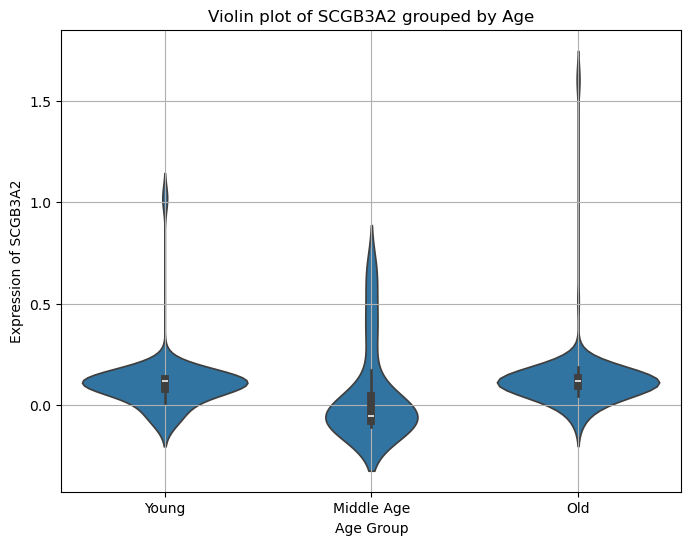

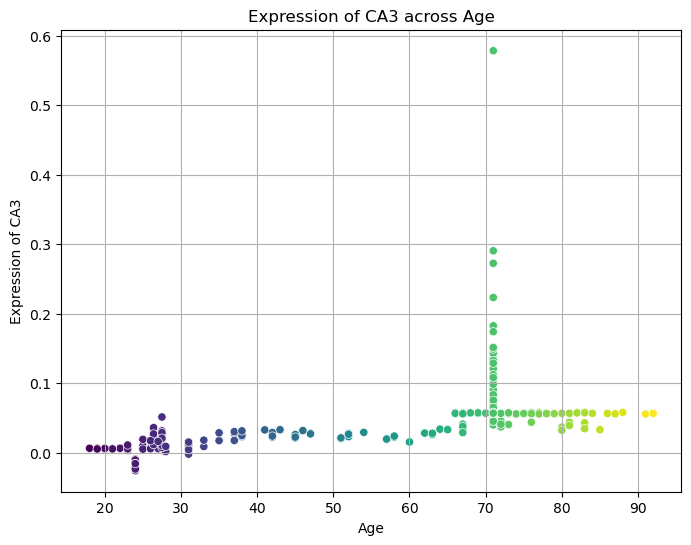

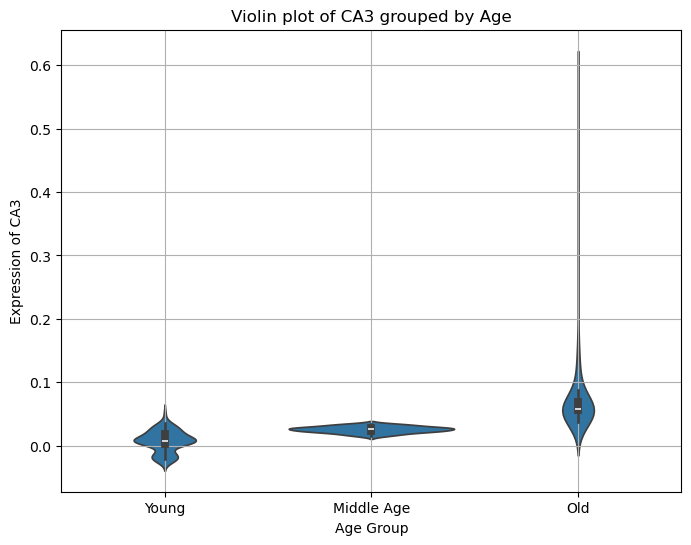

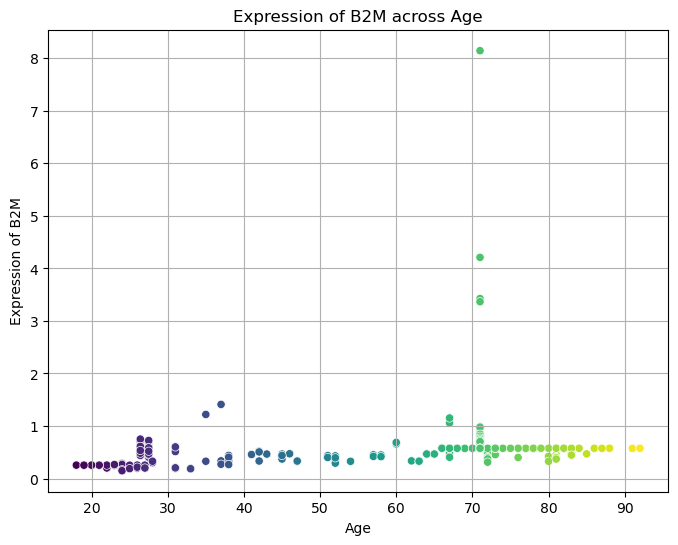

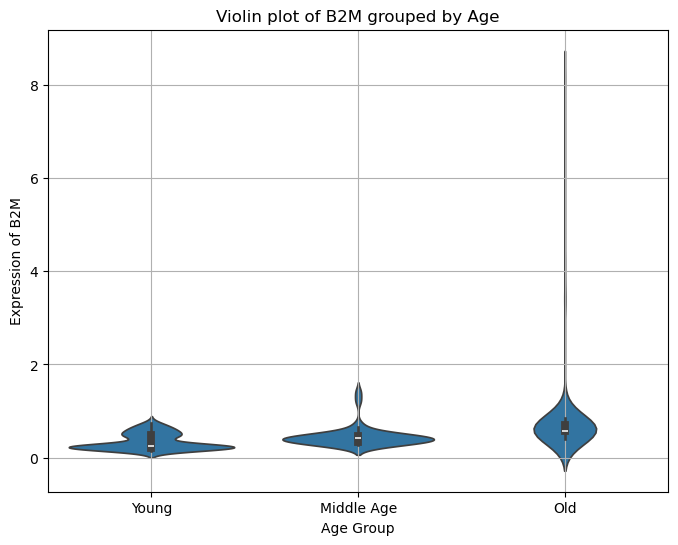

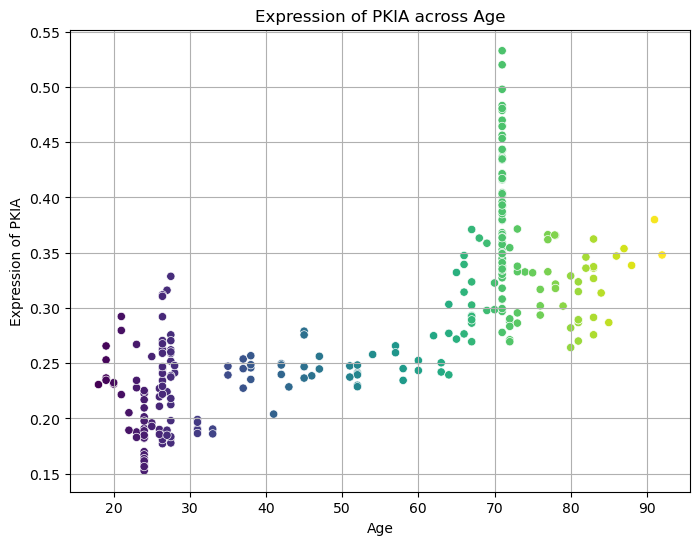

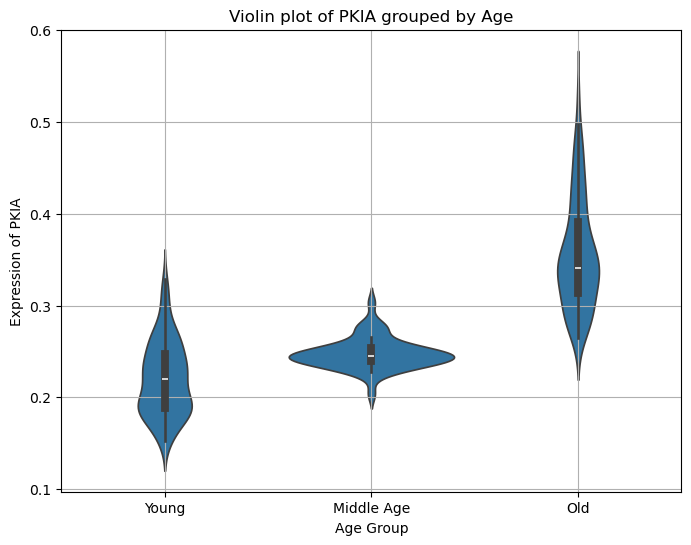

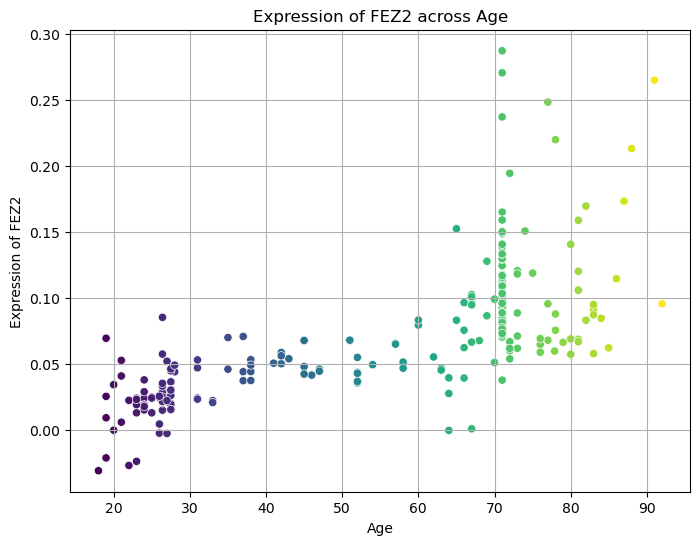

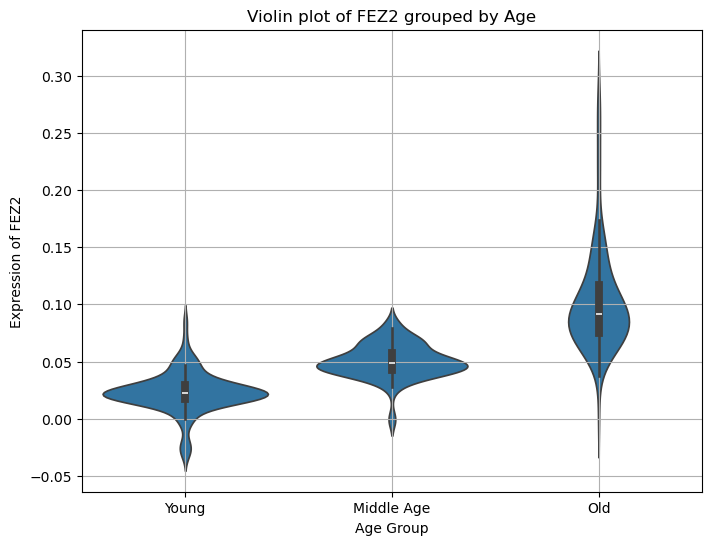

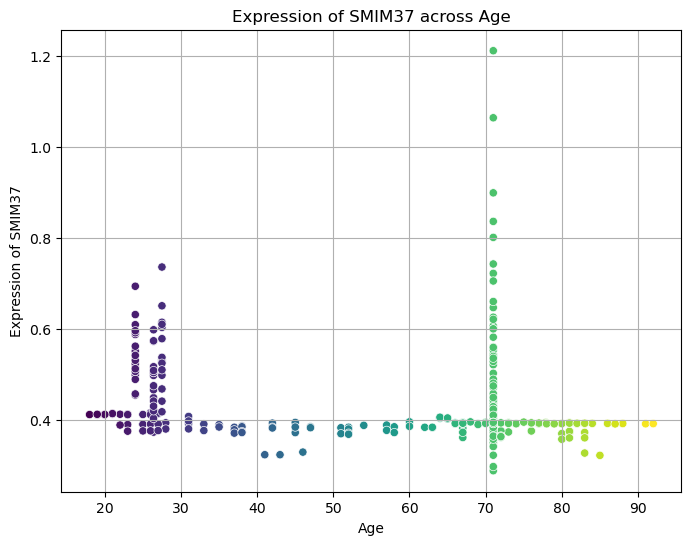

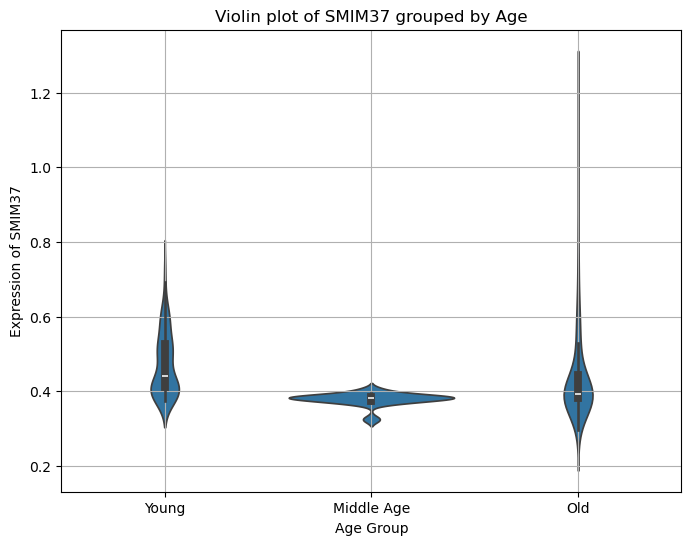

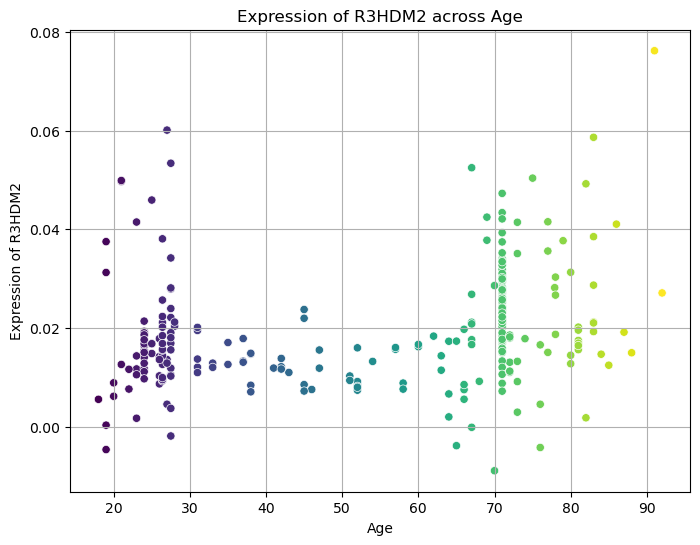

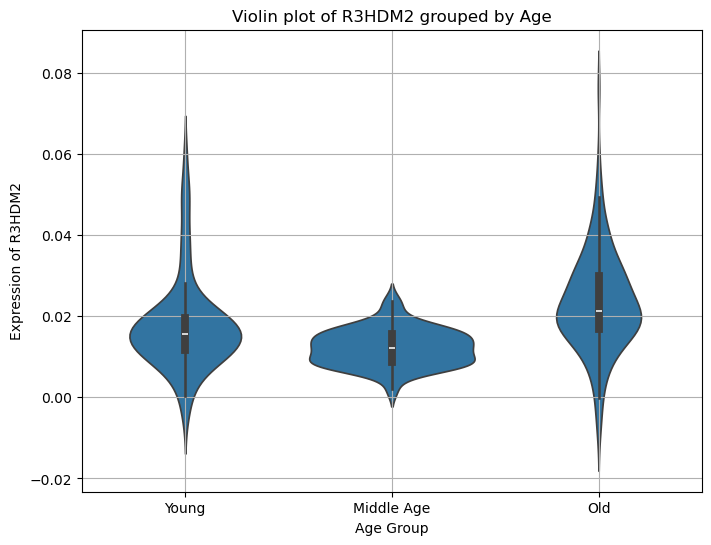

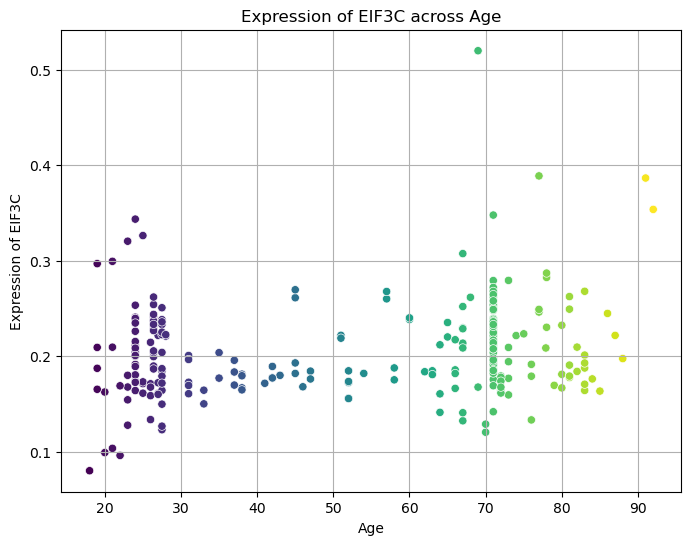

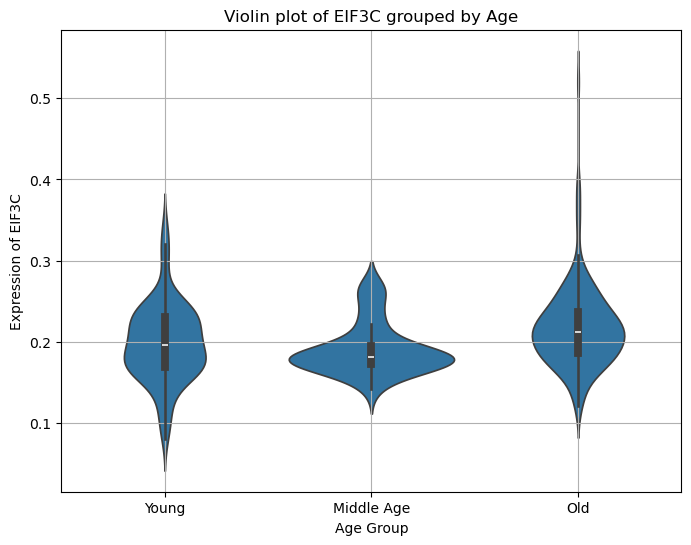

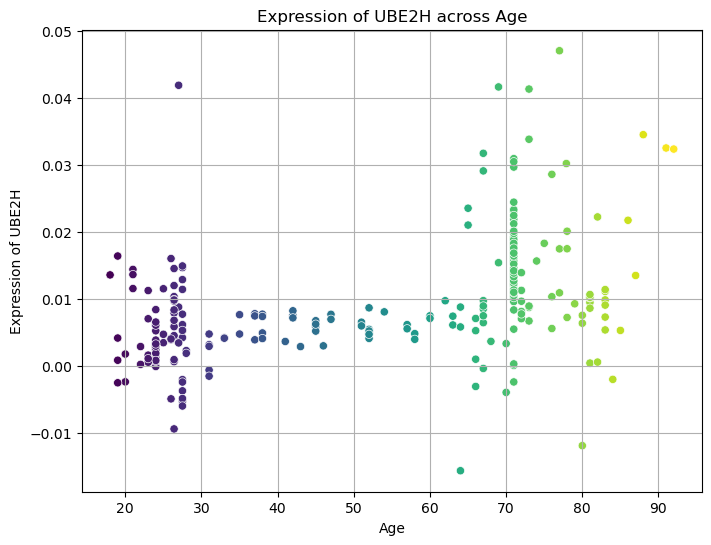

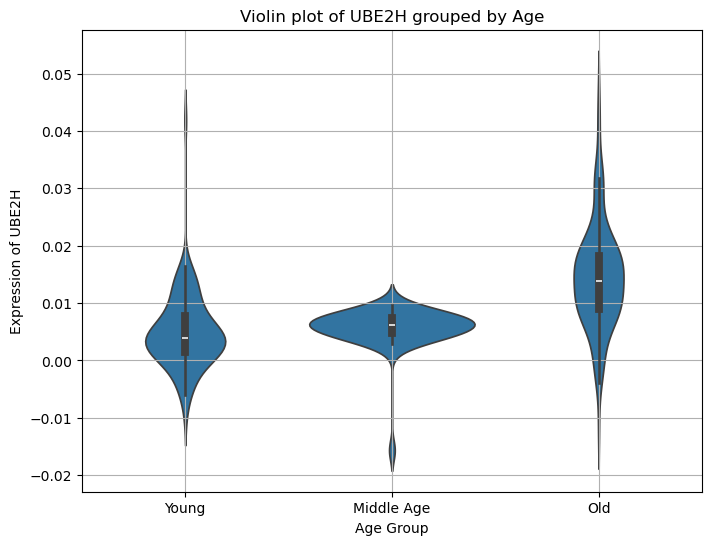

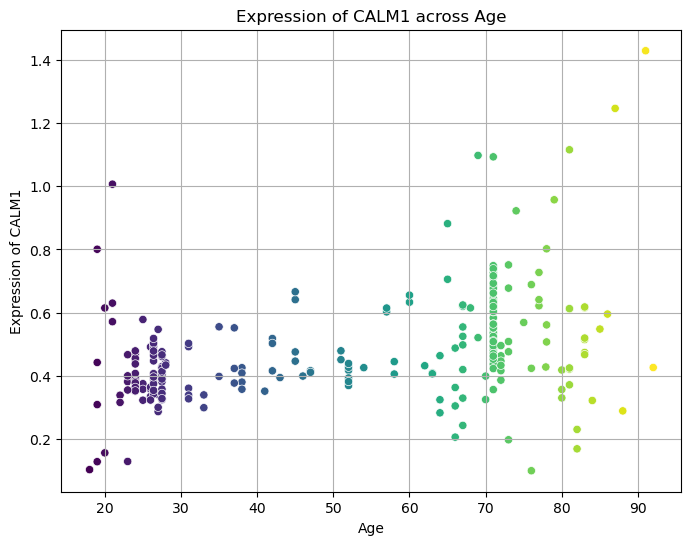

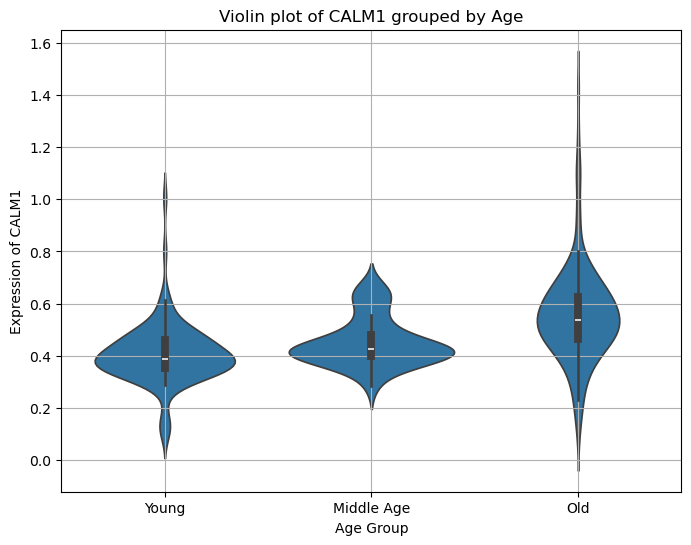

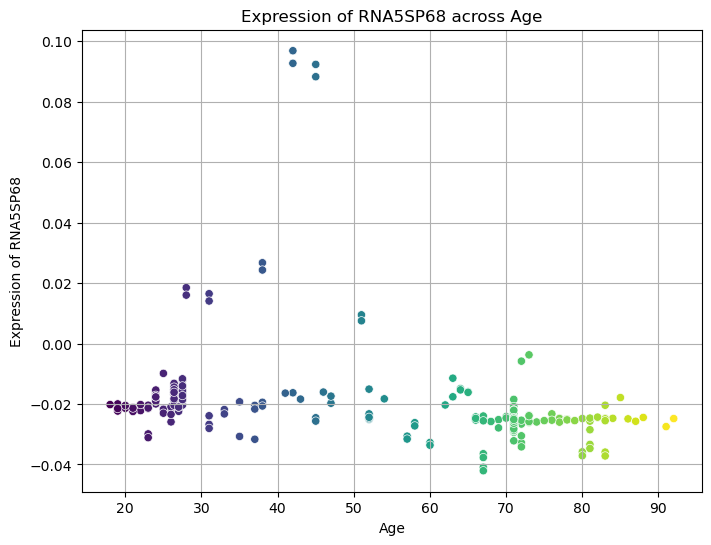

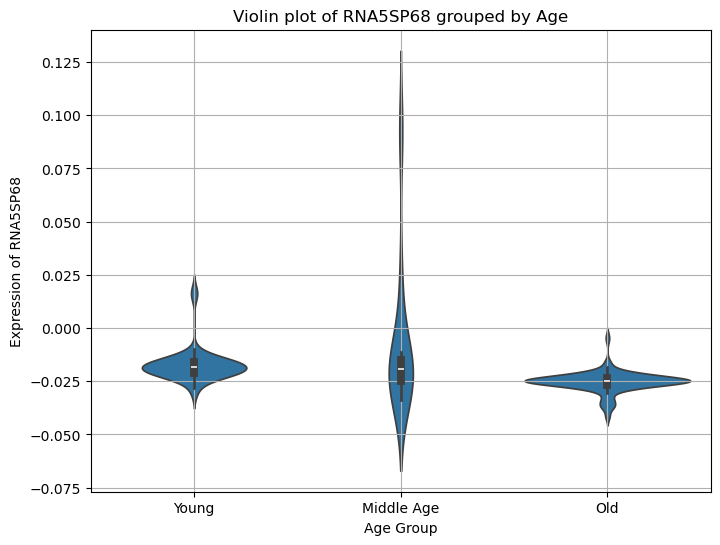

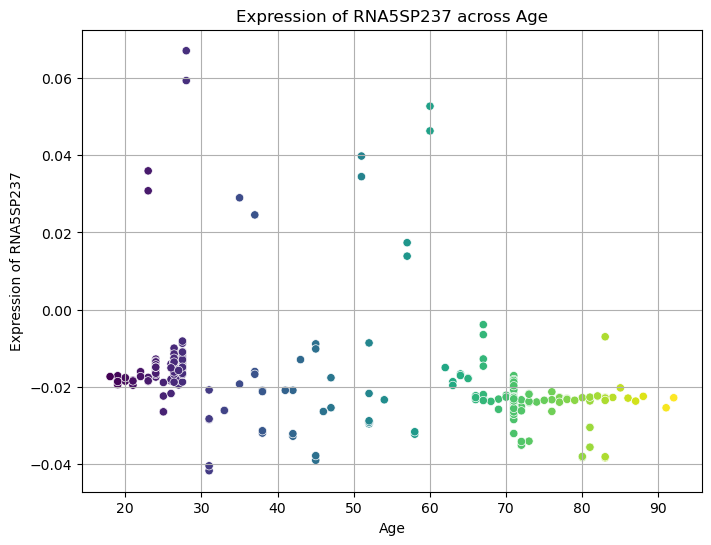

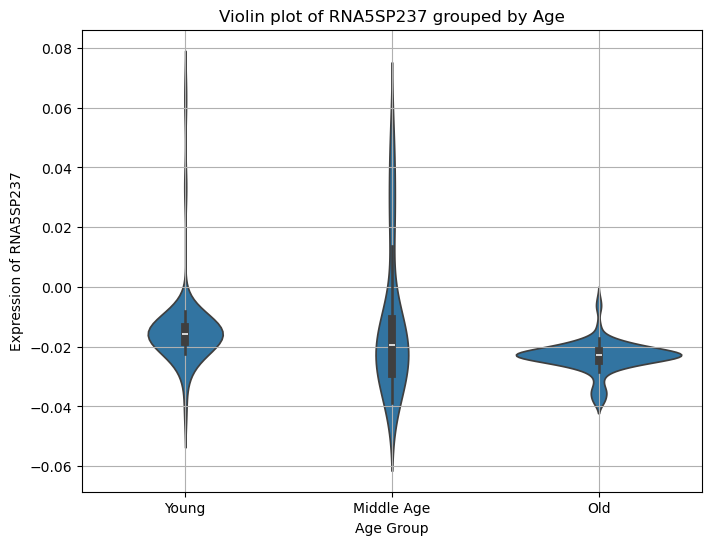

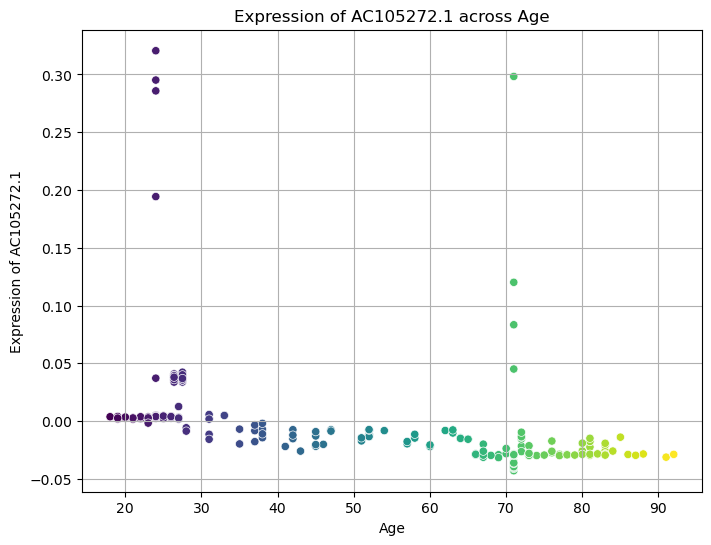

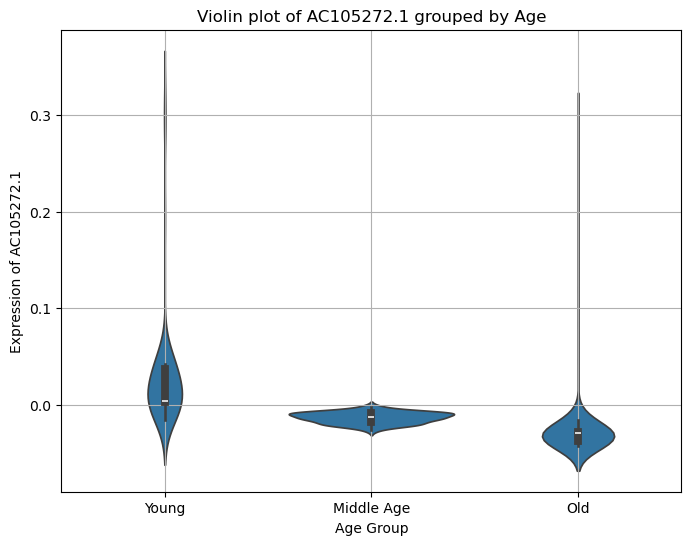

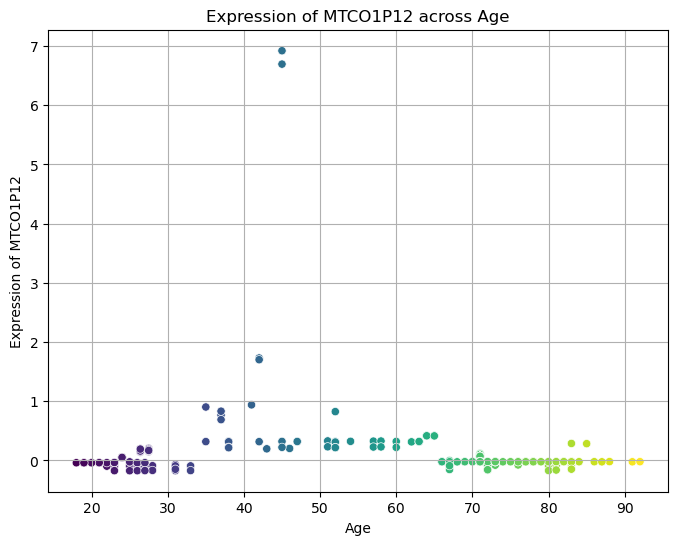

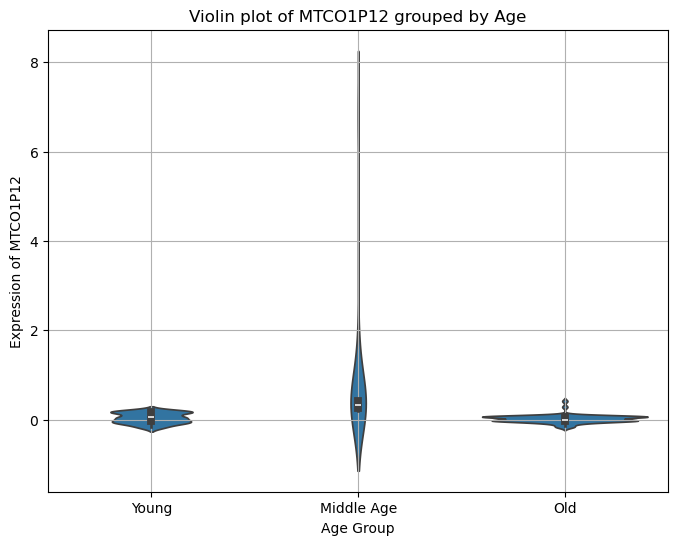

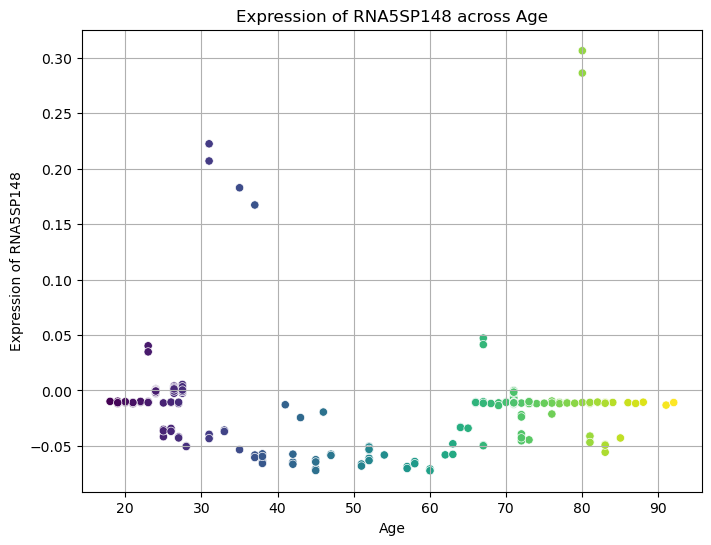

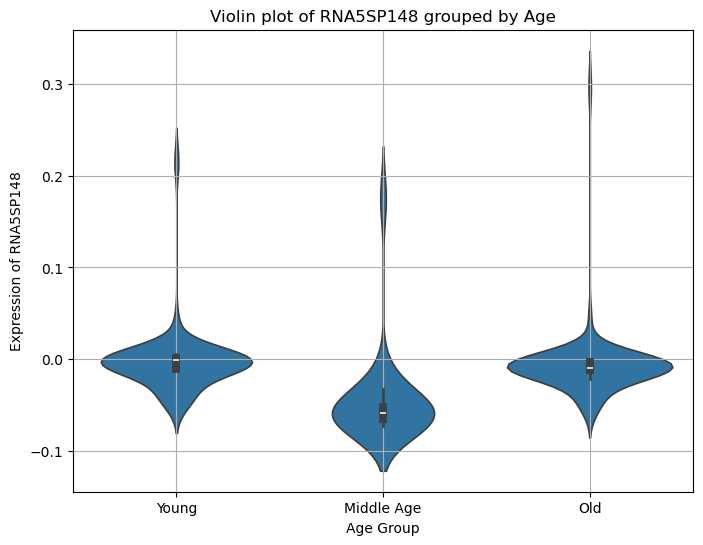

In [7]:
for gene in genes:
    gene_profile(expression_data, gene, save = f"plots/expression_intersection_{gene}")

In [8]:
bcs = []
for gene in genes:
    curve_code = get_change_curve(expression_data, gene)
    if 'B' in curve_code and 'C' in curve_code:
        bcs.append(gene)
    

In [ ]:
create_violin_pdf(gene_data = expression_data, genes=genes, output_file="data/intersection_all_violin_plots_BC_age.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_age)
create_violin_pdf(gene_data = expression_data, genes=genes, output_file="data/intersection_all_violin_plots_BC_age_and_sex.pdf", title="Gene Violin Plots", violin_function=violin_plot_grouped_by_sex_and_age_group)


In [9]:
bs = []
for gene in genes:
    curve_code = get_change_curve(expression_data, gene)
    if 'B' in curve_code:
        bs.append(gene)
bs

['GABRP',
 'MICU1',
 'PARK7',
 'SBDS',
 'MEIS2',
 'ALDOA',
 'FAM177A1',
 'SCGB3A2',
 'CA3',
 'B2M',
 'PKIA',
 'FEZ2',
 'SMIM37',
 'R3HDM2',
 'EIF3C',
 'UBE2H',
 'CALM1',
 'RNA5SP68',
 'MTCO1P12',
 'RNA5SP148']

In [10]:
cs = []
for gene in genes:
    curve_code = get_change_curve(expression_data, gene)
    if 'C' in curve_code:
        cs.append(gene)
cs

['HCFC1R1',
 'SBDS',
 'MEIS2',
 'ALDOA',
 'TSPAN7',
 'SMIM37',
 'R3HDM2',
 'RNA5SP68',
 'RNA5SP237',
 'AC105272.1',
 'MTCO1P12',
 'RNA5SP148']

In [ ]:
for gene in cs:
    gene_profile(expression_data, gene, save = f"plots/expression_C_{gene}")

In [ ]:
for gene in bs:
    gene_profile(expression_data, gene, save = f"plots/expression_B_{gene}")

In [13]:
bcs

['SBDS',
 'MEIS2',
 'ALDOA',
 'SMIM37',
 'R3HDM2',
 'RNA5SP68',
 'MTCO1P12',
 'RNA5SP148']

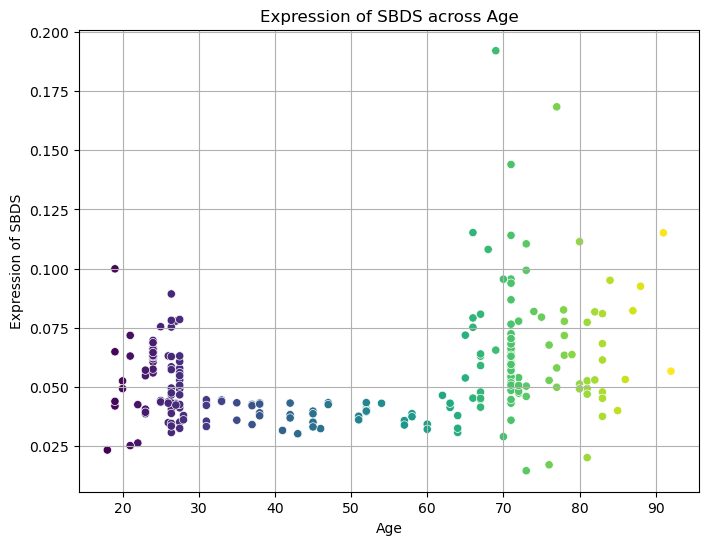

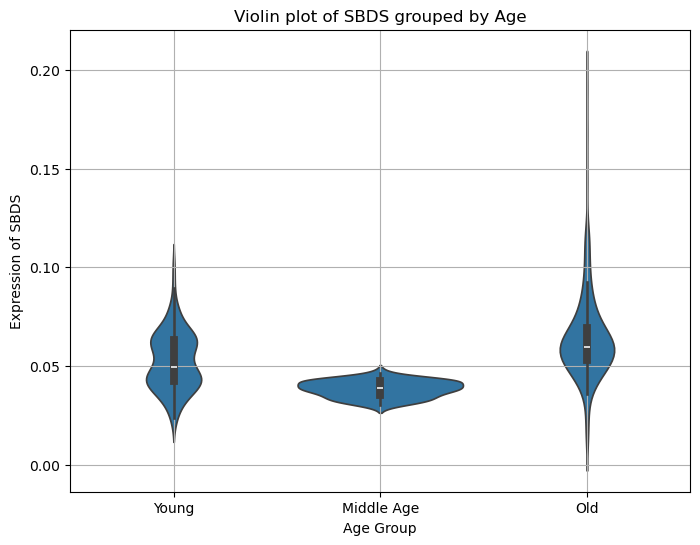

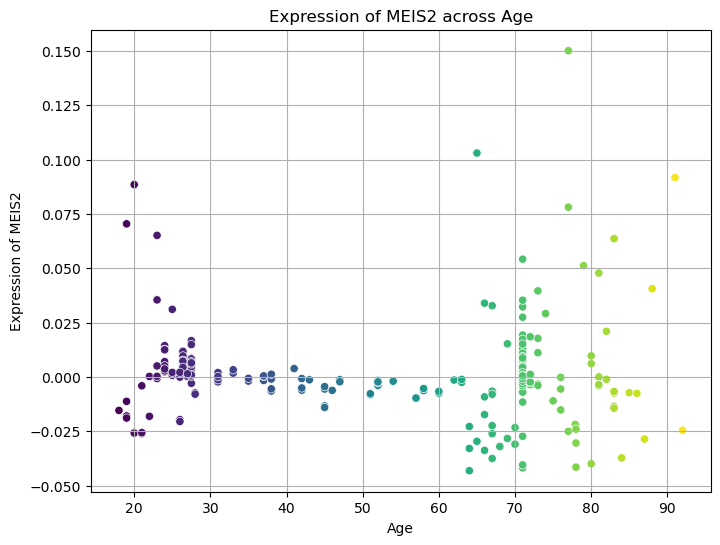

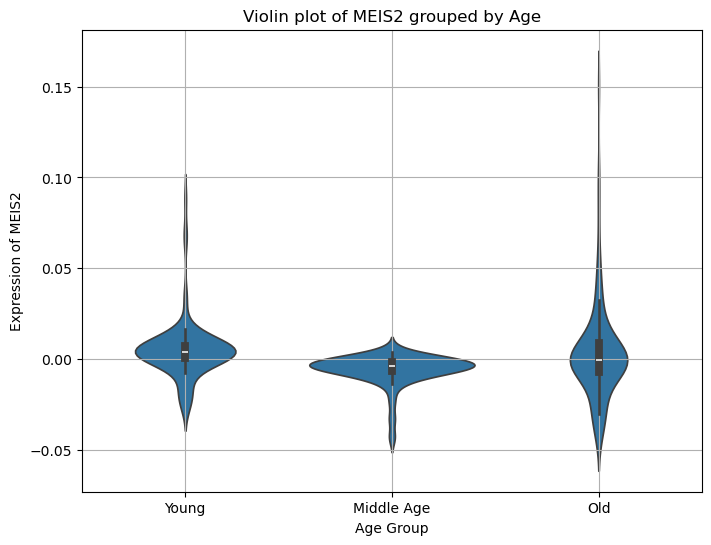

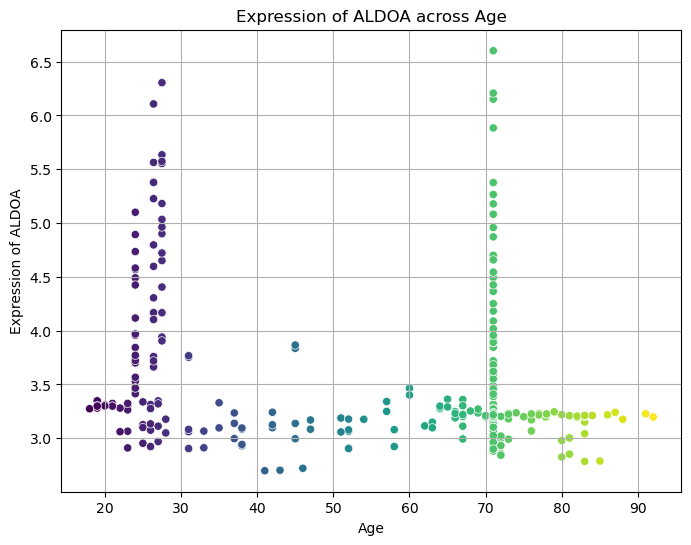

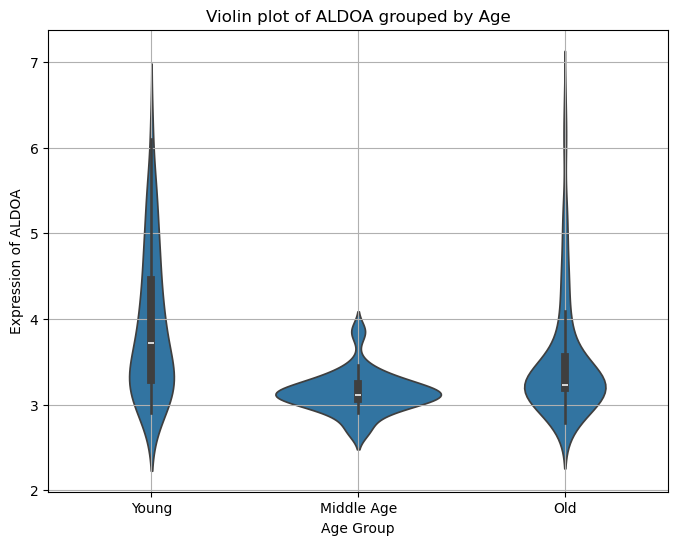

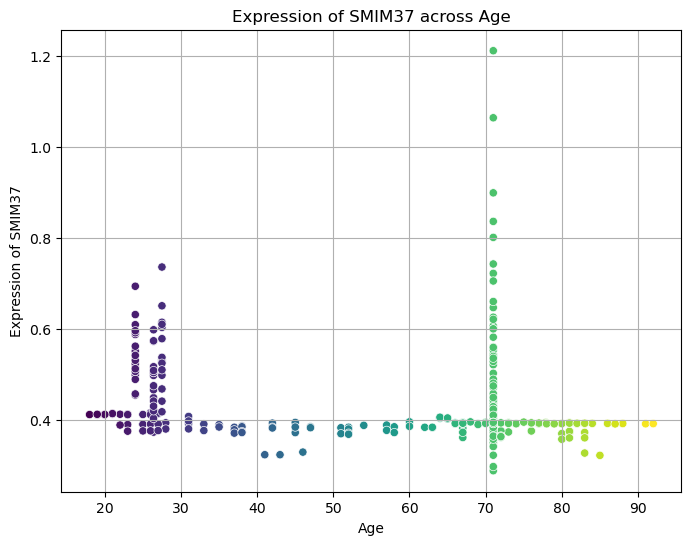

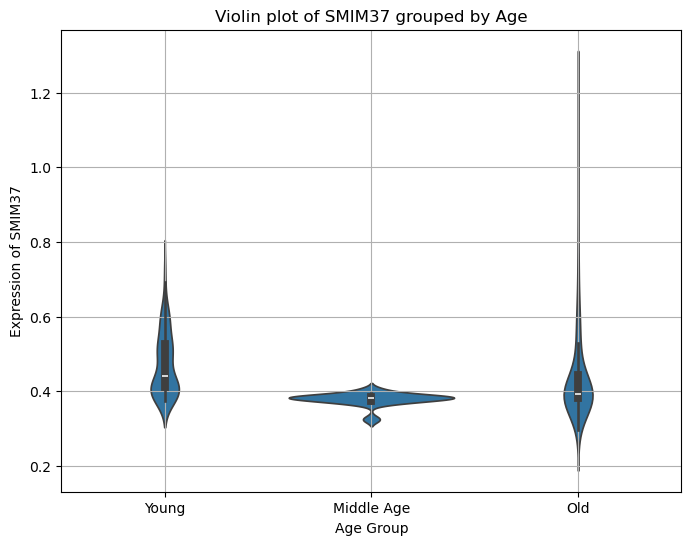

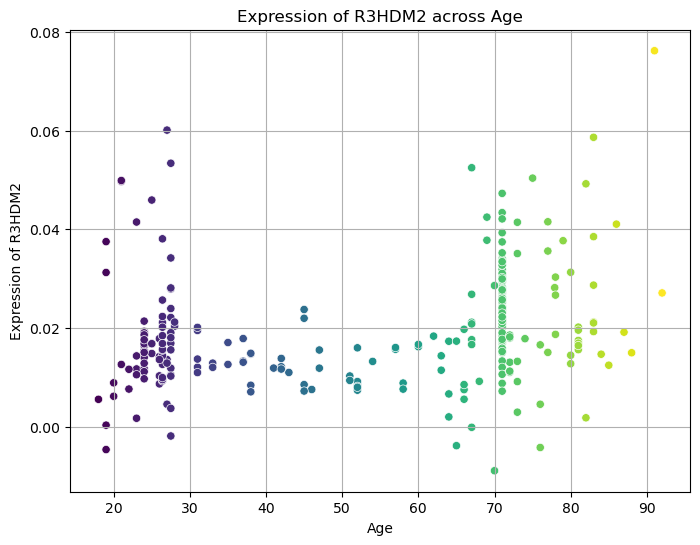

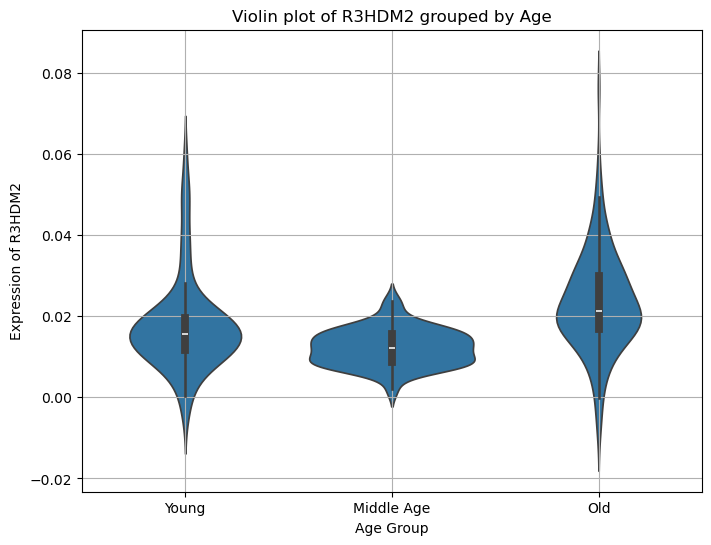

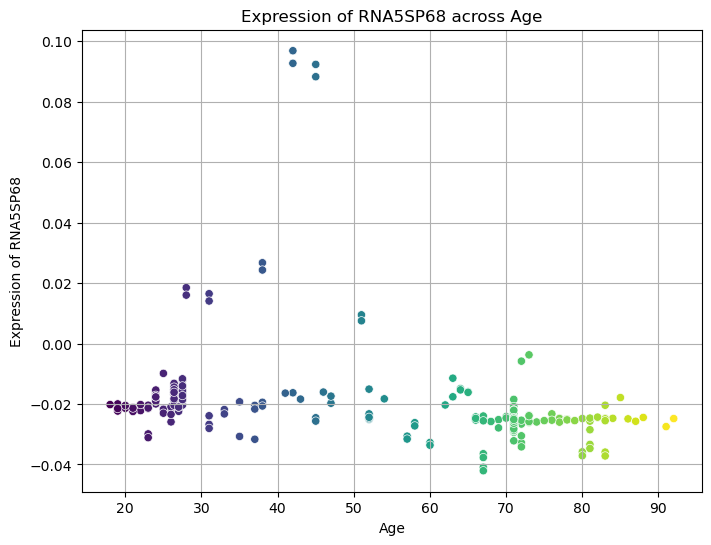

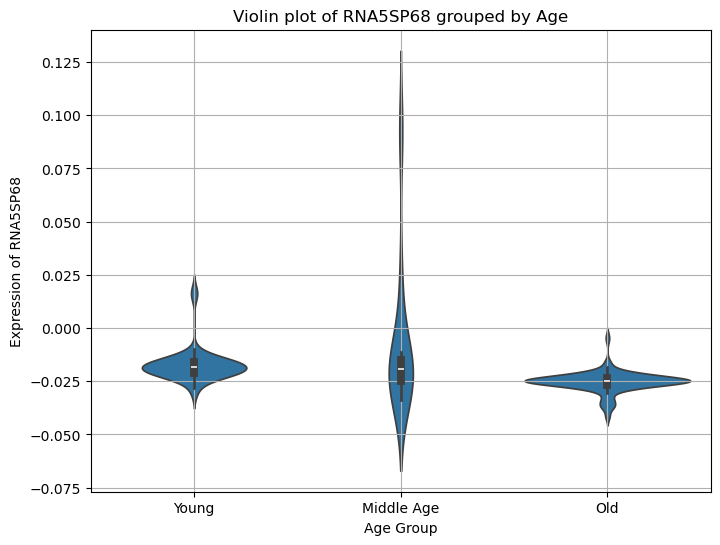

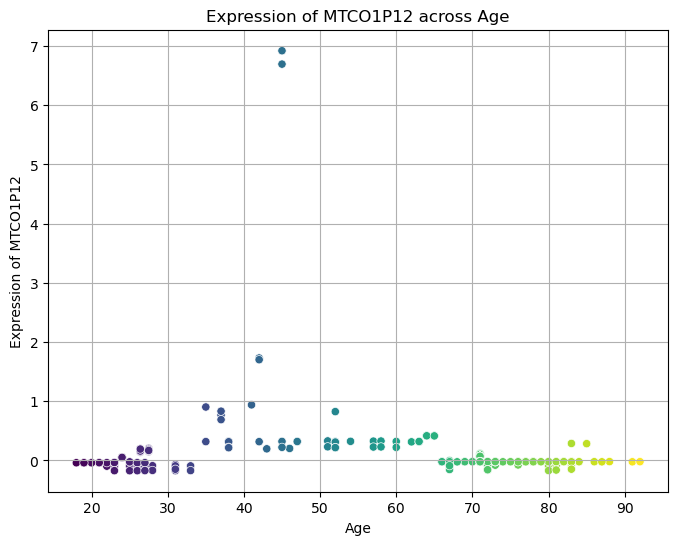

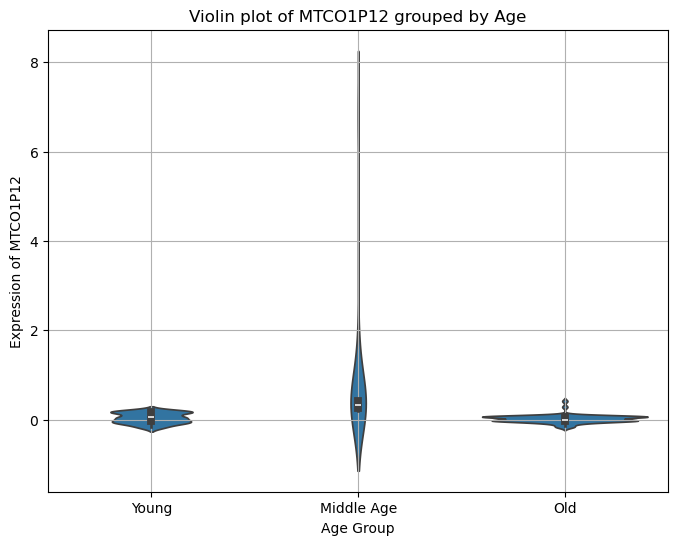

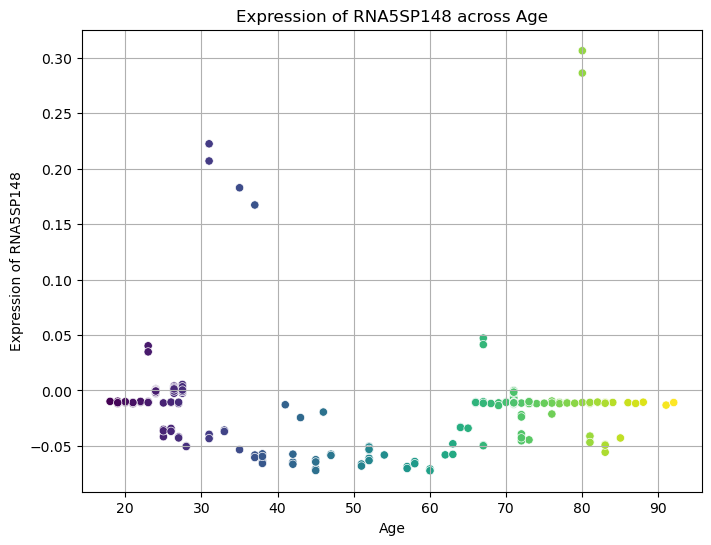

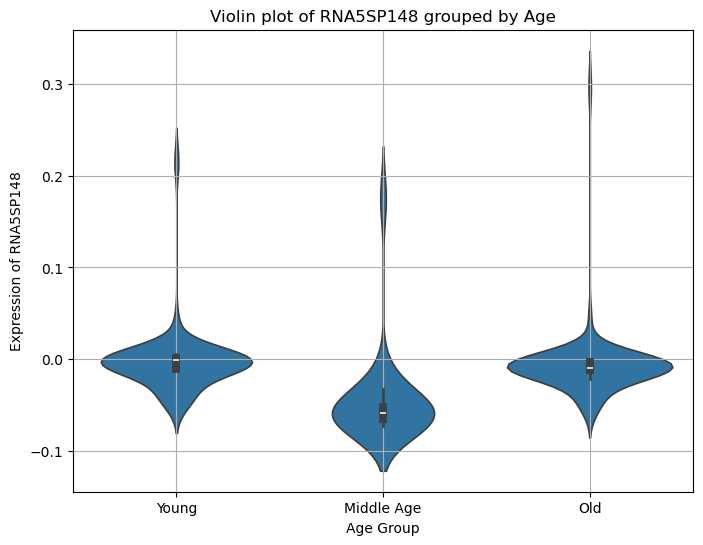

In [14]:
for gene in bcs:
    gene_profile(expression_data, gene, save = f"plots/expression_BC_{gene}")

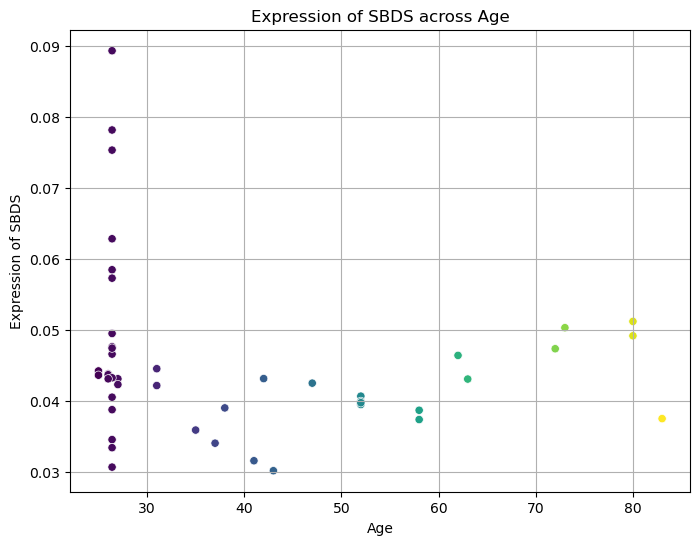

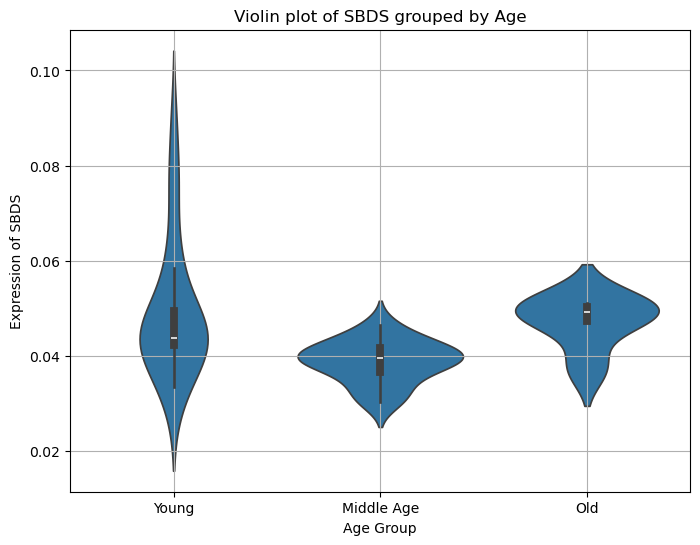

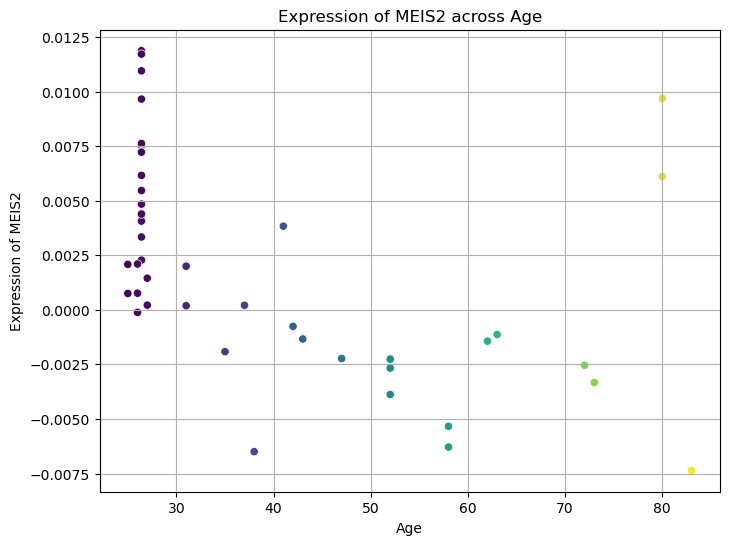

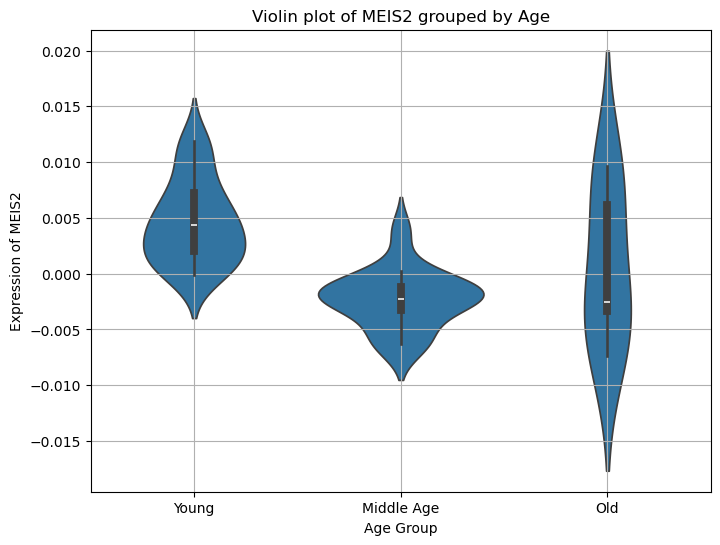

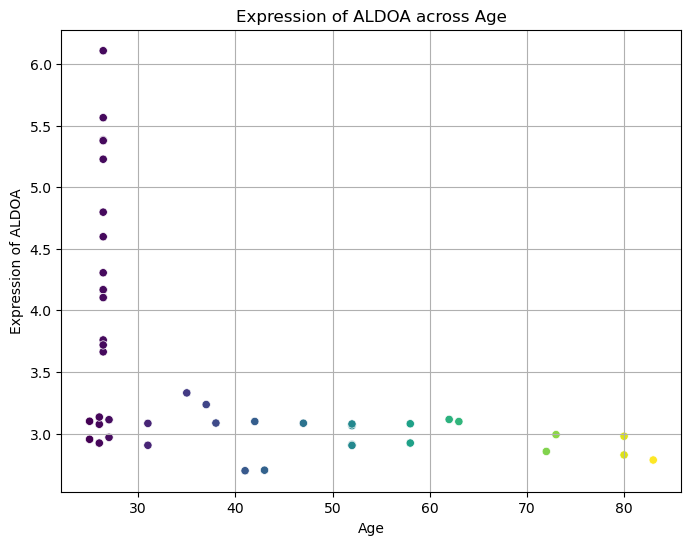

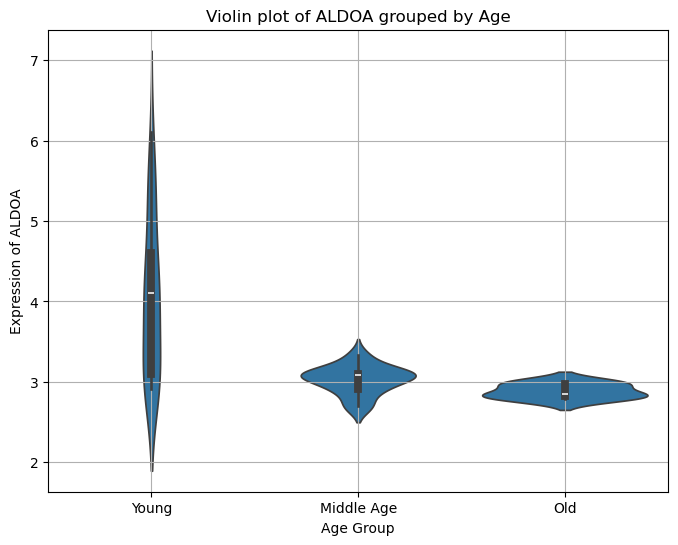

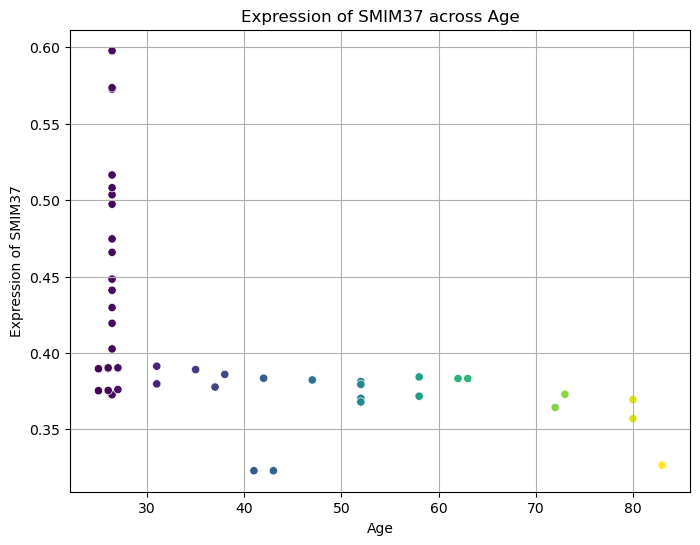

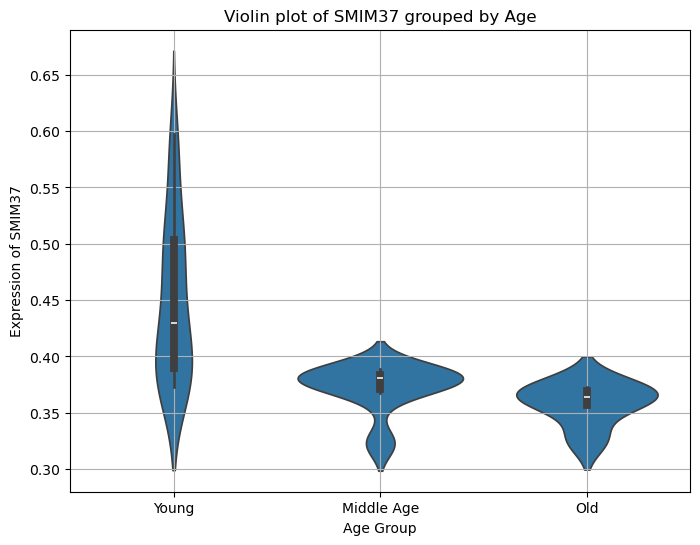

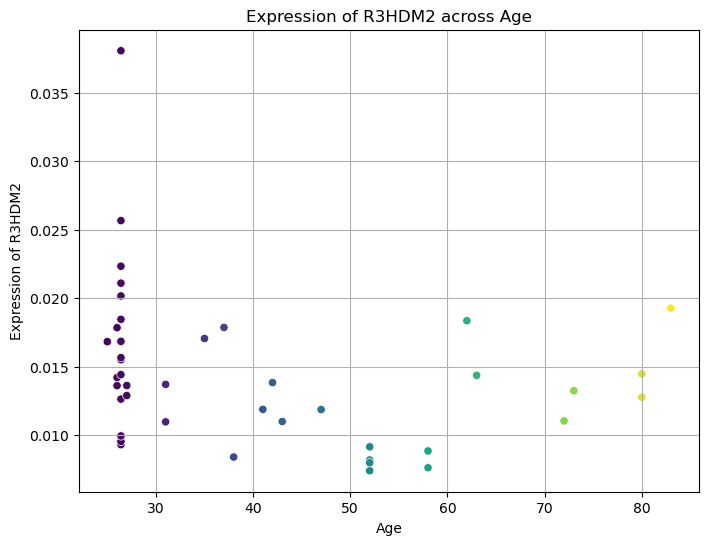

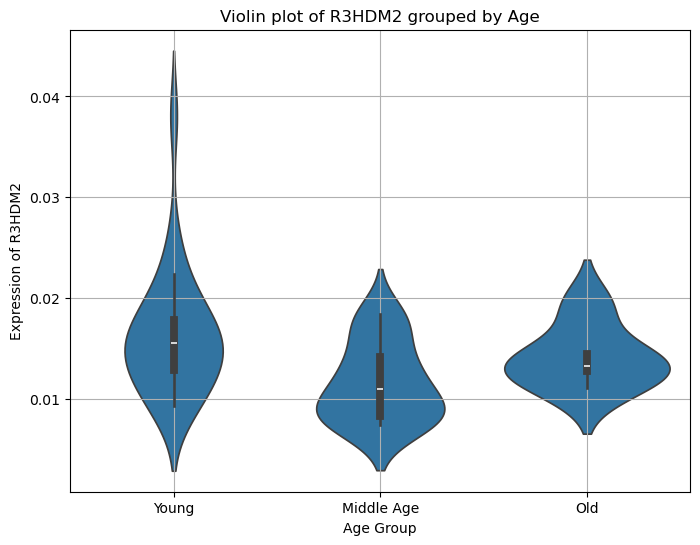

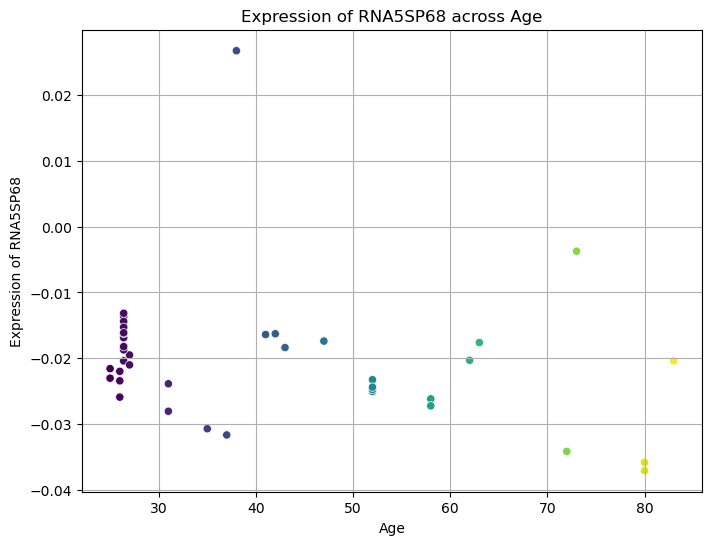

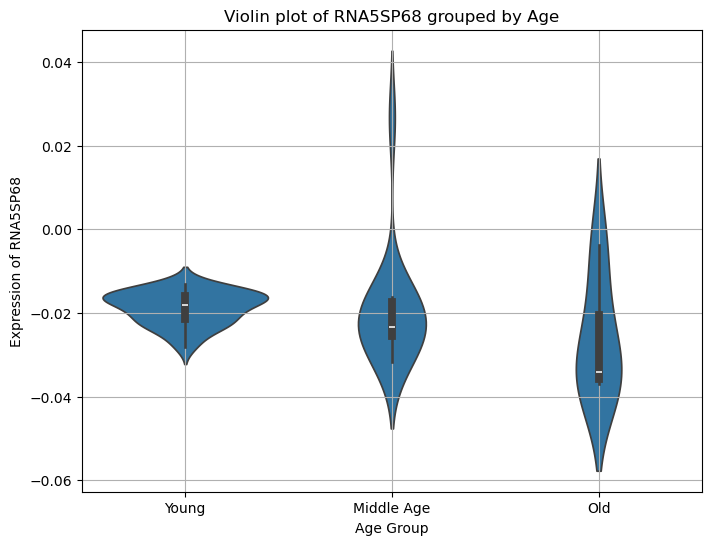

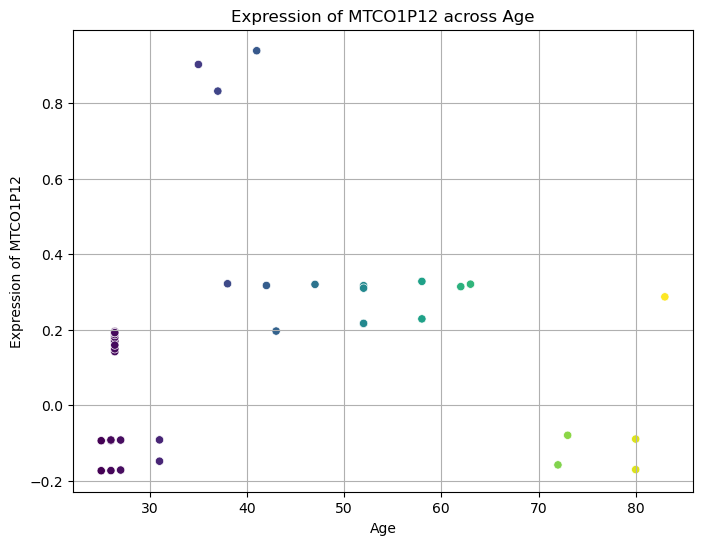

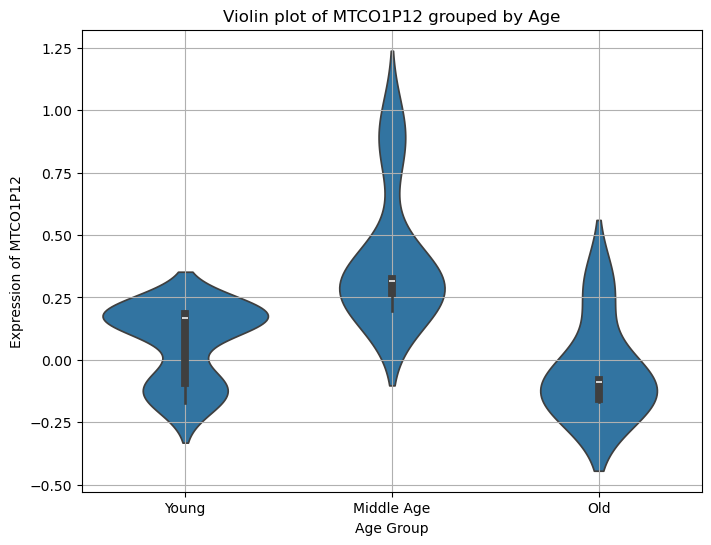

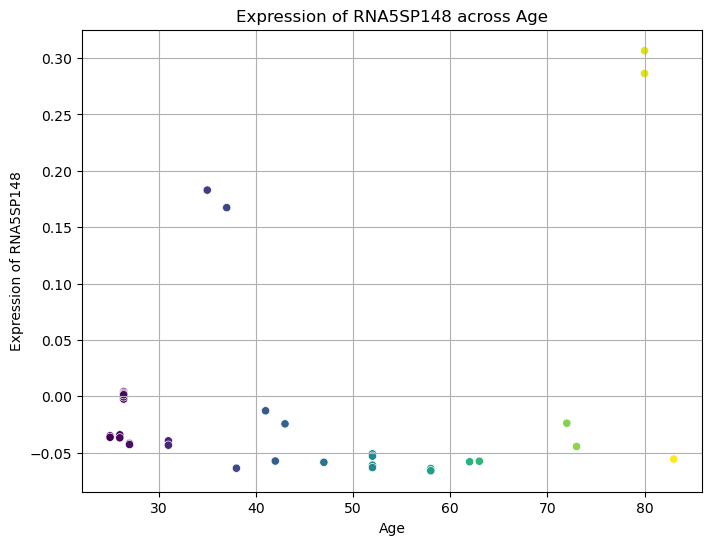

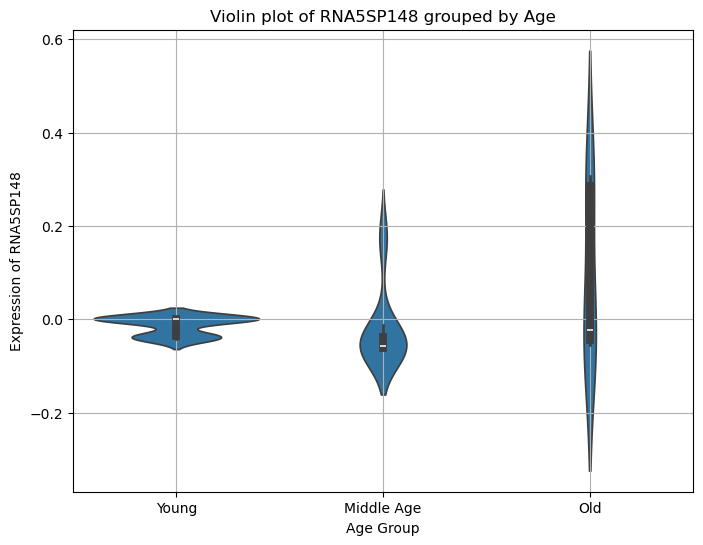

In [15]:
for gene in bcs:
    gene_profile(female_expression, gene, save = f"plots/female_{gene}")

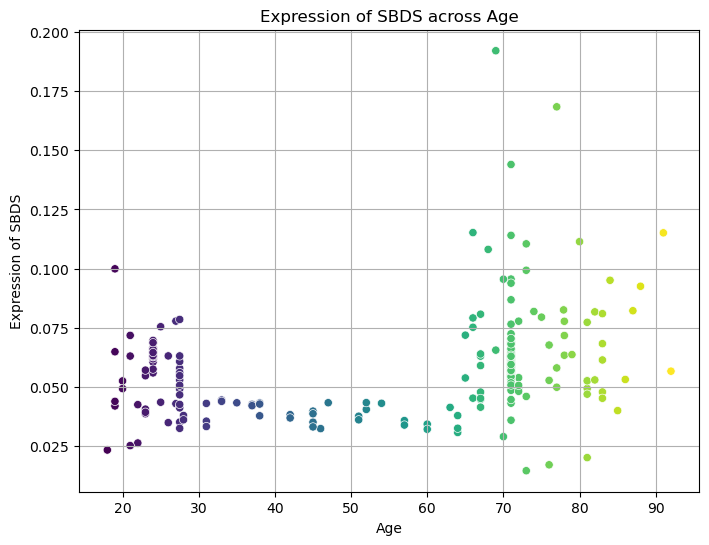

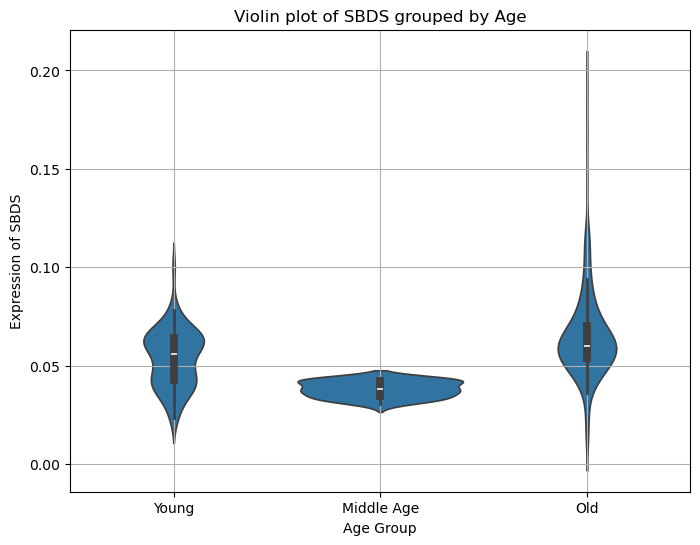

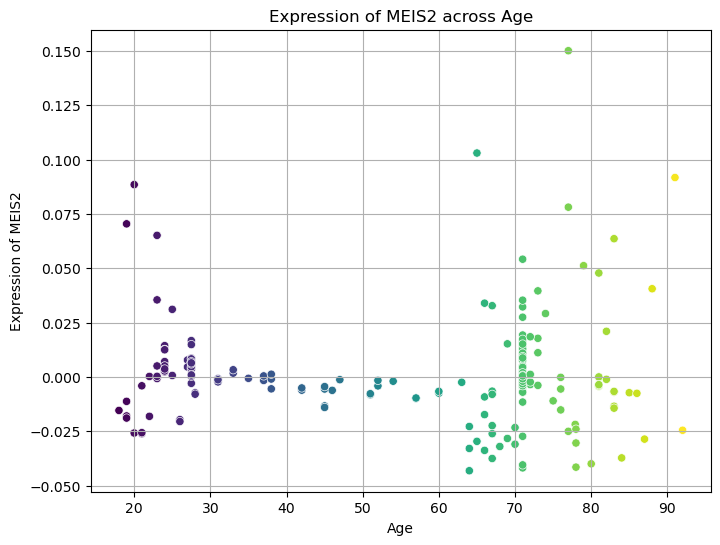

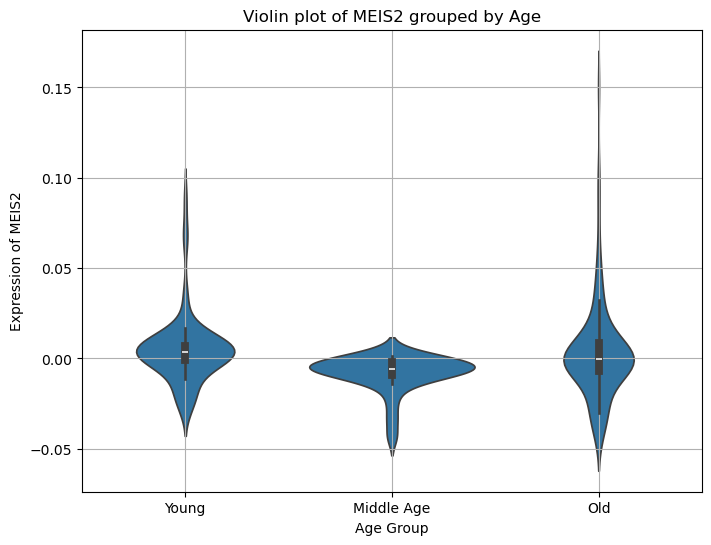

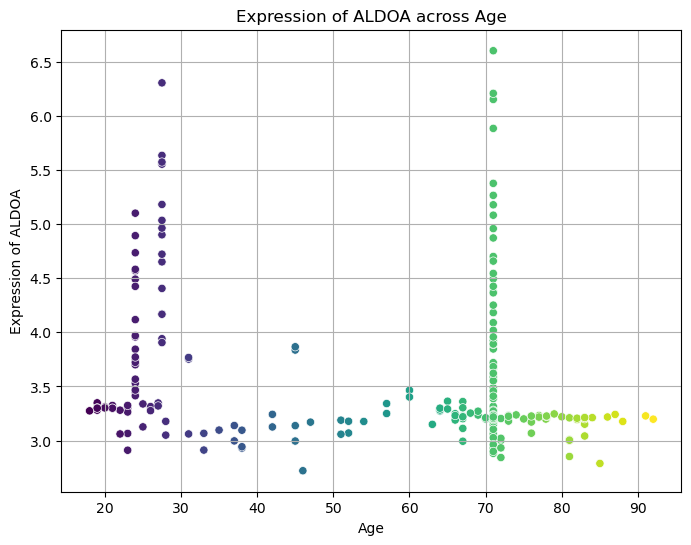

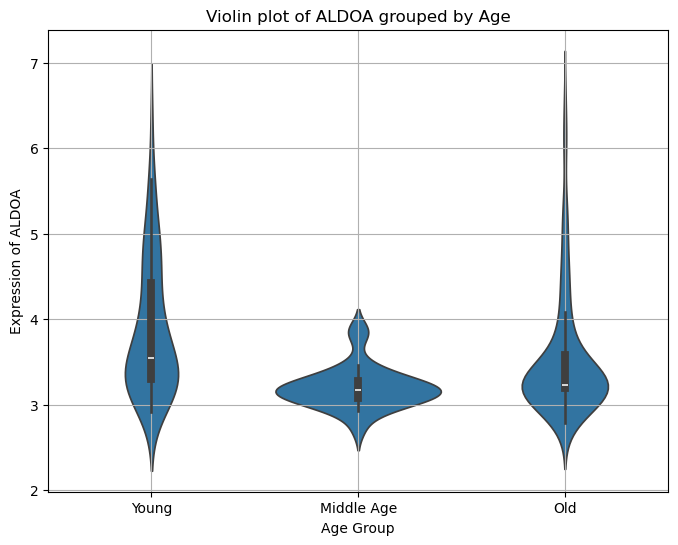

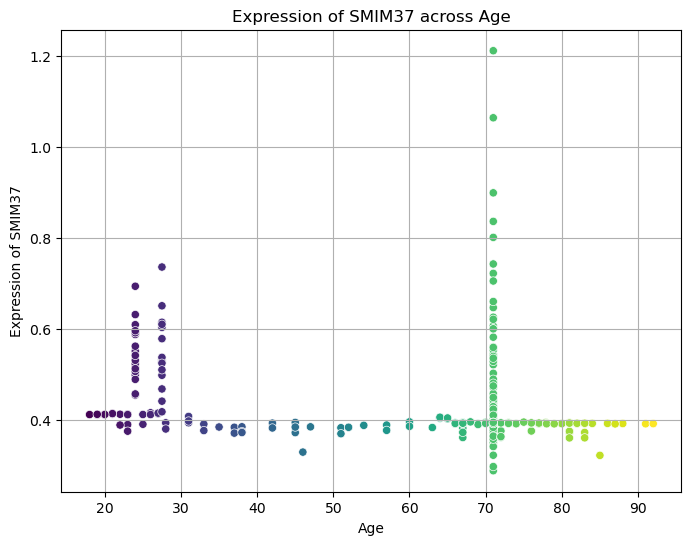

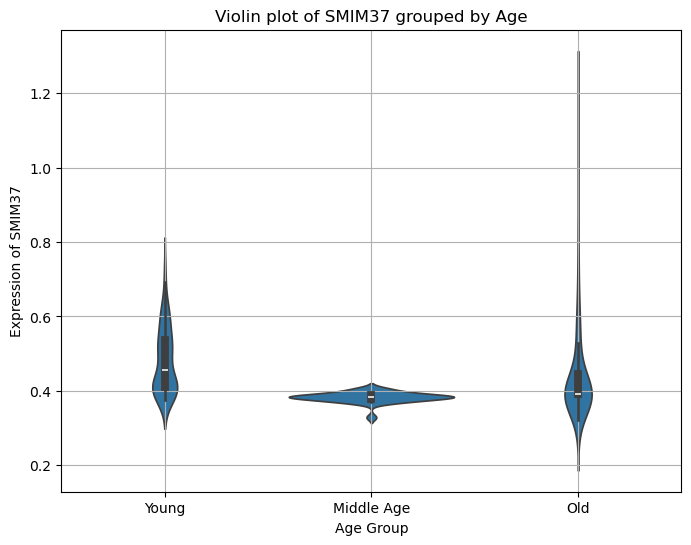

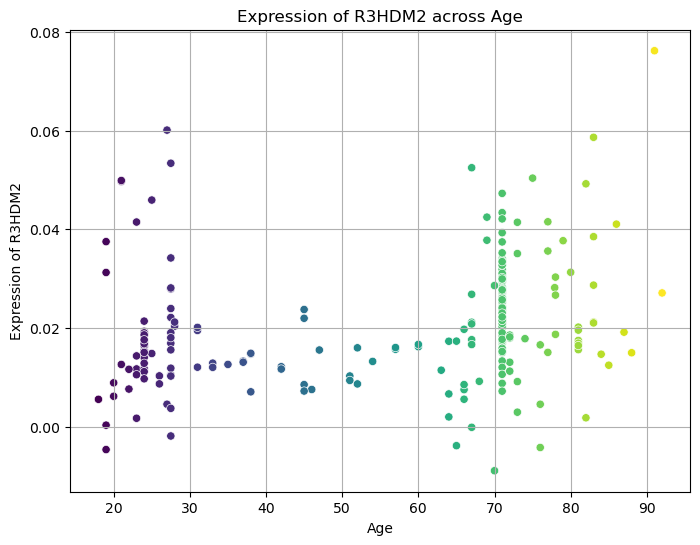

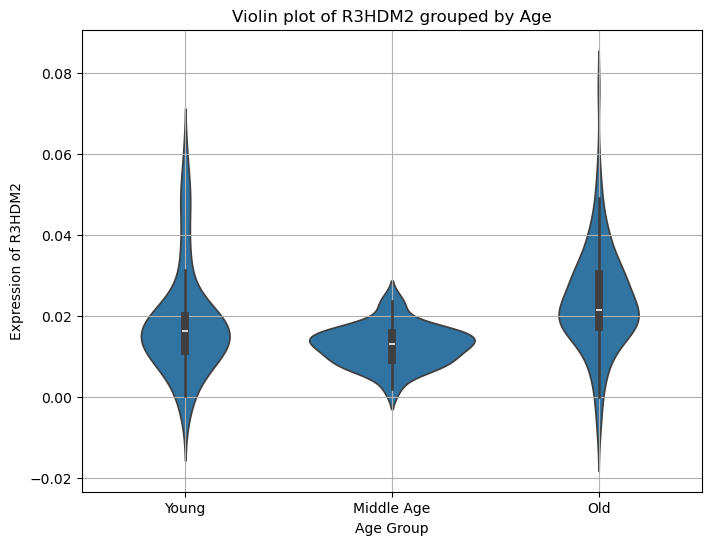

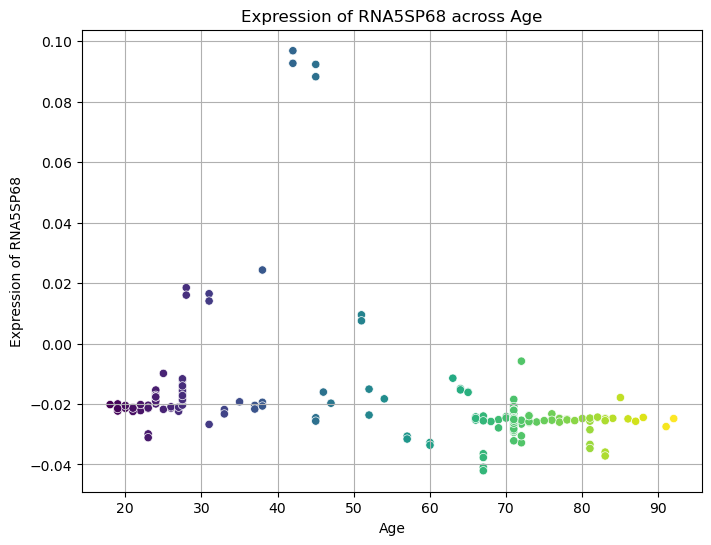

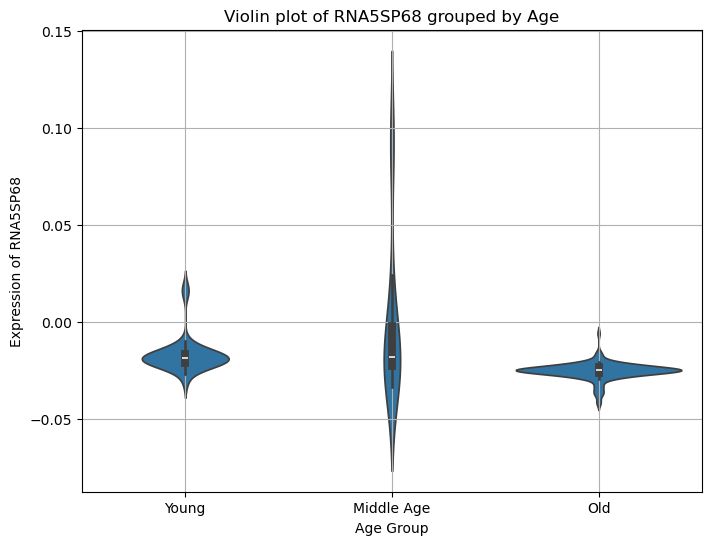

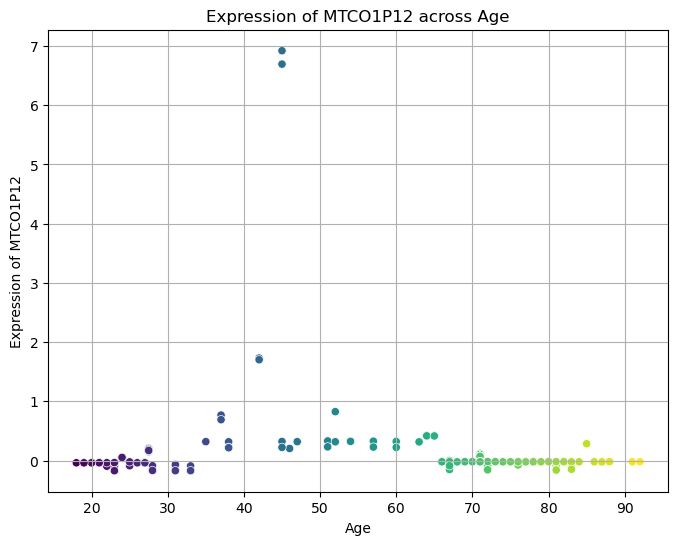

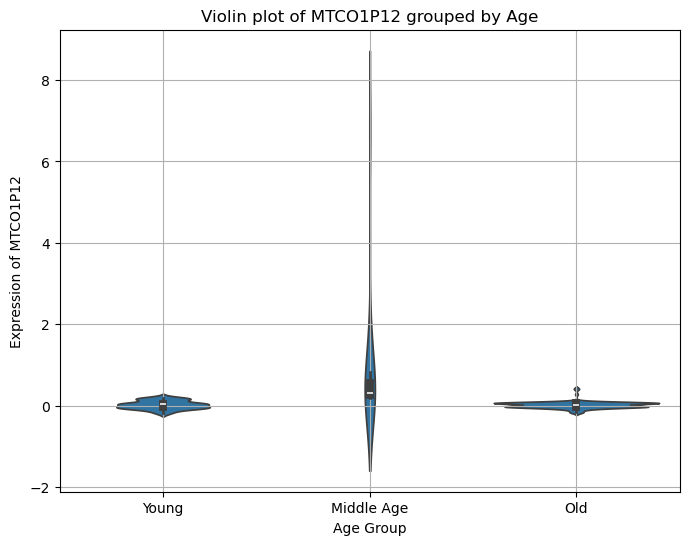

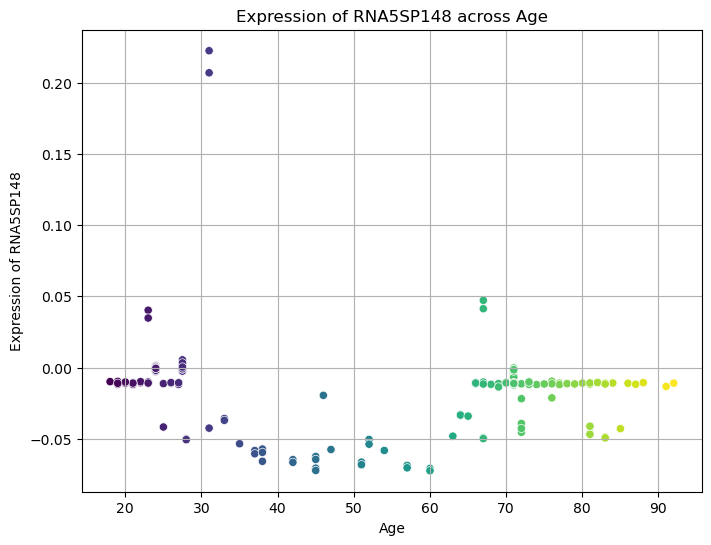

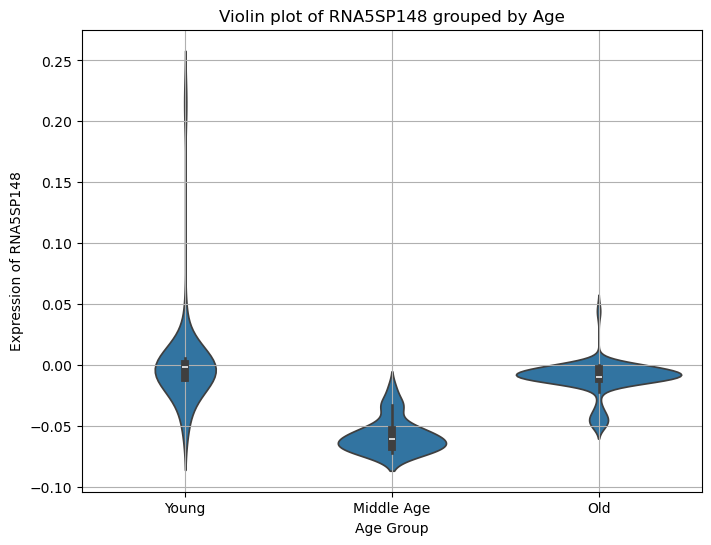

In [16]:
for gene in bcs:
    gene_profile(male_expression, gene, save = f"plots/male_{gene}")